In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from xmm_py_spec import plotting_settings
plotting_settings.set_mpl()

In [2]:
target_columns = [
 'src_num',
 'obs_id',
 'ons_start_date',
 'pn_ontime',
 'm1_ontime',
 'm2_ontime']


In [3]:
src_5359_df = pd.read_csv('../data/source_201237001010017_5359_results.csv')
src_5359_M1_df = pd.read_csv('../data/source_201237001010017_5359_individual_M1_results.csv')
# src_5359_clustered_df = pd.read_csv('../data/source_201237001010017_5359_clustered_results.csv')
# # src_5359_old_df = pd.read_csv('../data/source_201237001010017_5359_results_old.csv')
# src_1430_df = pd.read_csv('../data/source_201237001015028_1430_results.csv')
# src_7170_df = pd.read_csv('../data/source_201237001015035_7170_results.csv')

In [ ]:
def plot_date_gamma(
        df, title, color, ax=None, pad=False, lolim=-0.5, uplim=3.1, alpha=.5
    ):

    if not ax:
        _, ax = plt.subplots(figsize=(10, 6))

    df['date_obs'] = pd.to_datetime(df['date_obs']).dt.floor('D')

    # Add date formatter
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    padding = pd.Timedelta(days=50)  # Add 30 days padding on each side

    x_delta = pd.Timedelta(days=-15) if pad else pd.Timedelta(days=0)

    ax.errorbar(
        x=df['date_obs'] + x_delta, y=df['mo2_PhoIndex_step_2d'],
        yerr=[df['mo2_PhoIndex_step_2d_nerr'], df['mo2_PhoIndex_step_2d_perr']],
        fmt='o', markersize=0, alpha=alpha, capsize=4, capthick=1.5, ecolor=color,
        lw=2, label=title
        )

    ax.scatter(
        x=df['date_obs'] + x_delta, y=df['mo2_PhoIndex_step_2d'],
        s=3, zorder=5, color='k'
        )

    ax.set_ylim(lolim, uplim)
    ax.set_xlim(
        pd.to_datetime('2000-04-27 03:34:45') - padding,
        pd.to_datetime('2002-12-04 04:47:08') + padding
    )
    ax.axhline(1.4, color='gray', ls='--', alpha=0.3)

    ax.set_ylabel('Г')

    ax.tick_params(axis='x', which='minor', length=0)
    ax.tick_params(axis='x', which='major', length=2)

    # ax.set_title(f'srcid {title}; ph*zph*zpo', loc='left')

    ax.legend(loc='upper left')

    plt.xticks(rotation=70)

    # plt.show()

    return ax

In [ ]:
def plot_date_gamma(
        df, title, color, ax=None, pad_days=None, lolim=-0.5, uplim=3.1, alpha=.5
    ):

    if not ax:
        _, ax = plt.subplots(figsize=(10, 6))

    df['date_obs'] = pd.to_datetime(df['date_obs']).dt.floor('D')

    # Add date formatter
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    padding = pd.Timedelta(days=50)  # Add 30 days padding on each side

    x_delta = pd.Timedelta(days=pad_days) if pad_days is not None else pd.Timedelta(days=0)

    ax.errorbar(
        x=df['date_obs'] + x_delta, y=df['mo2_PhoIndex_step_2d'],
        yerr=[df['mo2_PhoIndex_step_2d_nerr'], df['mo2_PhoIndex_step_2d_perr']],
        fmt='o', markersize=0, alpha=alpha, capsize=4, capthick=1.5, ecolor=color,
        lw=2, label=title
        )

    ax.scatter(
        x=df['date_obs'] + x_delta, y=df['mo2_PhoIndex_step_2d'],
        s=3, zorder=5, color='k'
        )

    ax.set_ylim(lolim, uplim)
    ax.set_xlim(
        pd.to_datetime('2000-04-27 03:34:45') - padding,
        pd.to_datetime('2002-12-04 04:47:08') + padding
    )
    ax.axhline(1.4, color='gray', ls='--', alpha=0.3)

    ax.set_ylabel('Г')

    ax.tick_params(axis='x', which='minor', length=0)
    ax.tick_params(axis='x', which='major', length=2)

    # ax.set_title(f'srcid {title}; ph*zph*zpo', loc='left')

    ax.legend(loc='upper left')

    plt.xticks(rotation=70)

    # plt.show()

    return ax

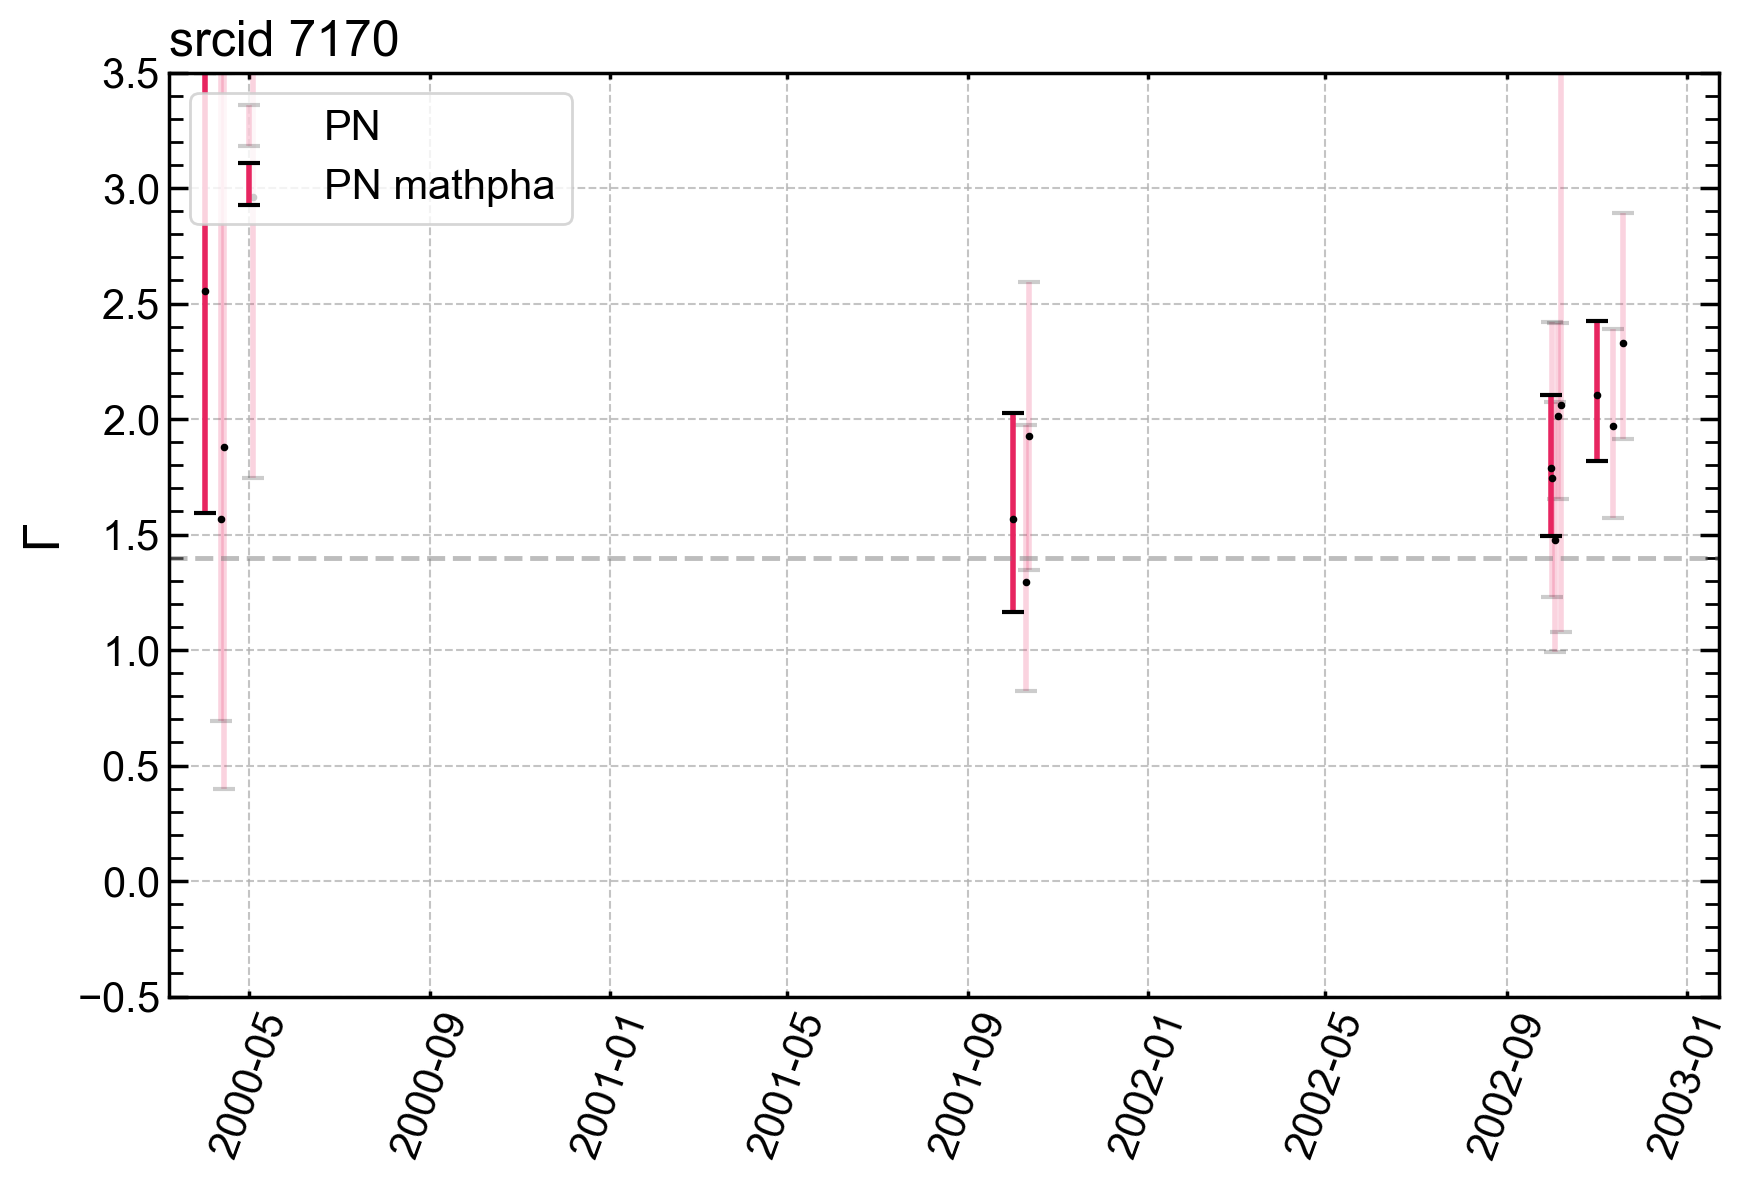

In [5]:
src_7170_PN_df = pd.read_csv('../data/source_201237001015035_7170_individual_PN_gap30_epicspeccombine_results.csv')
ax = plot_date_gamma(src_7170_PN_df, "PN", color='C1', alpha=0.2, pad=True, uplim=3.5)

src_7170_PN_addspec_df = pd.read_csv('../data/source_201237001015035_7170_clustered_PN_gap30_addspec_results.csv')
plot_date_gamma(src_7170_PN_addspec_df, "PN mathpha", color='C1', alpha=1, ax=ax, uplim=3.5)

ax.set_title('srcid 7170', loc='left')

plt.show()

# src_7170_PN_sascombine_df = pd.read_csv('../data/source_201237001015035_7170_clustered_PN_gap30_epicspeccombine_results.csv')
# plot_date_gamma(src_7170_PN_sascombine_df, "sascombine", color='C1', alpha=1, ax=ax, uplim=4)

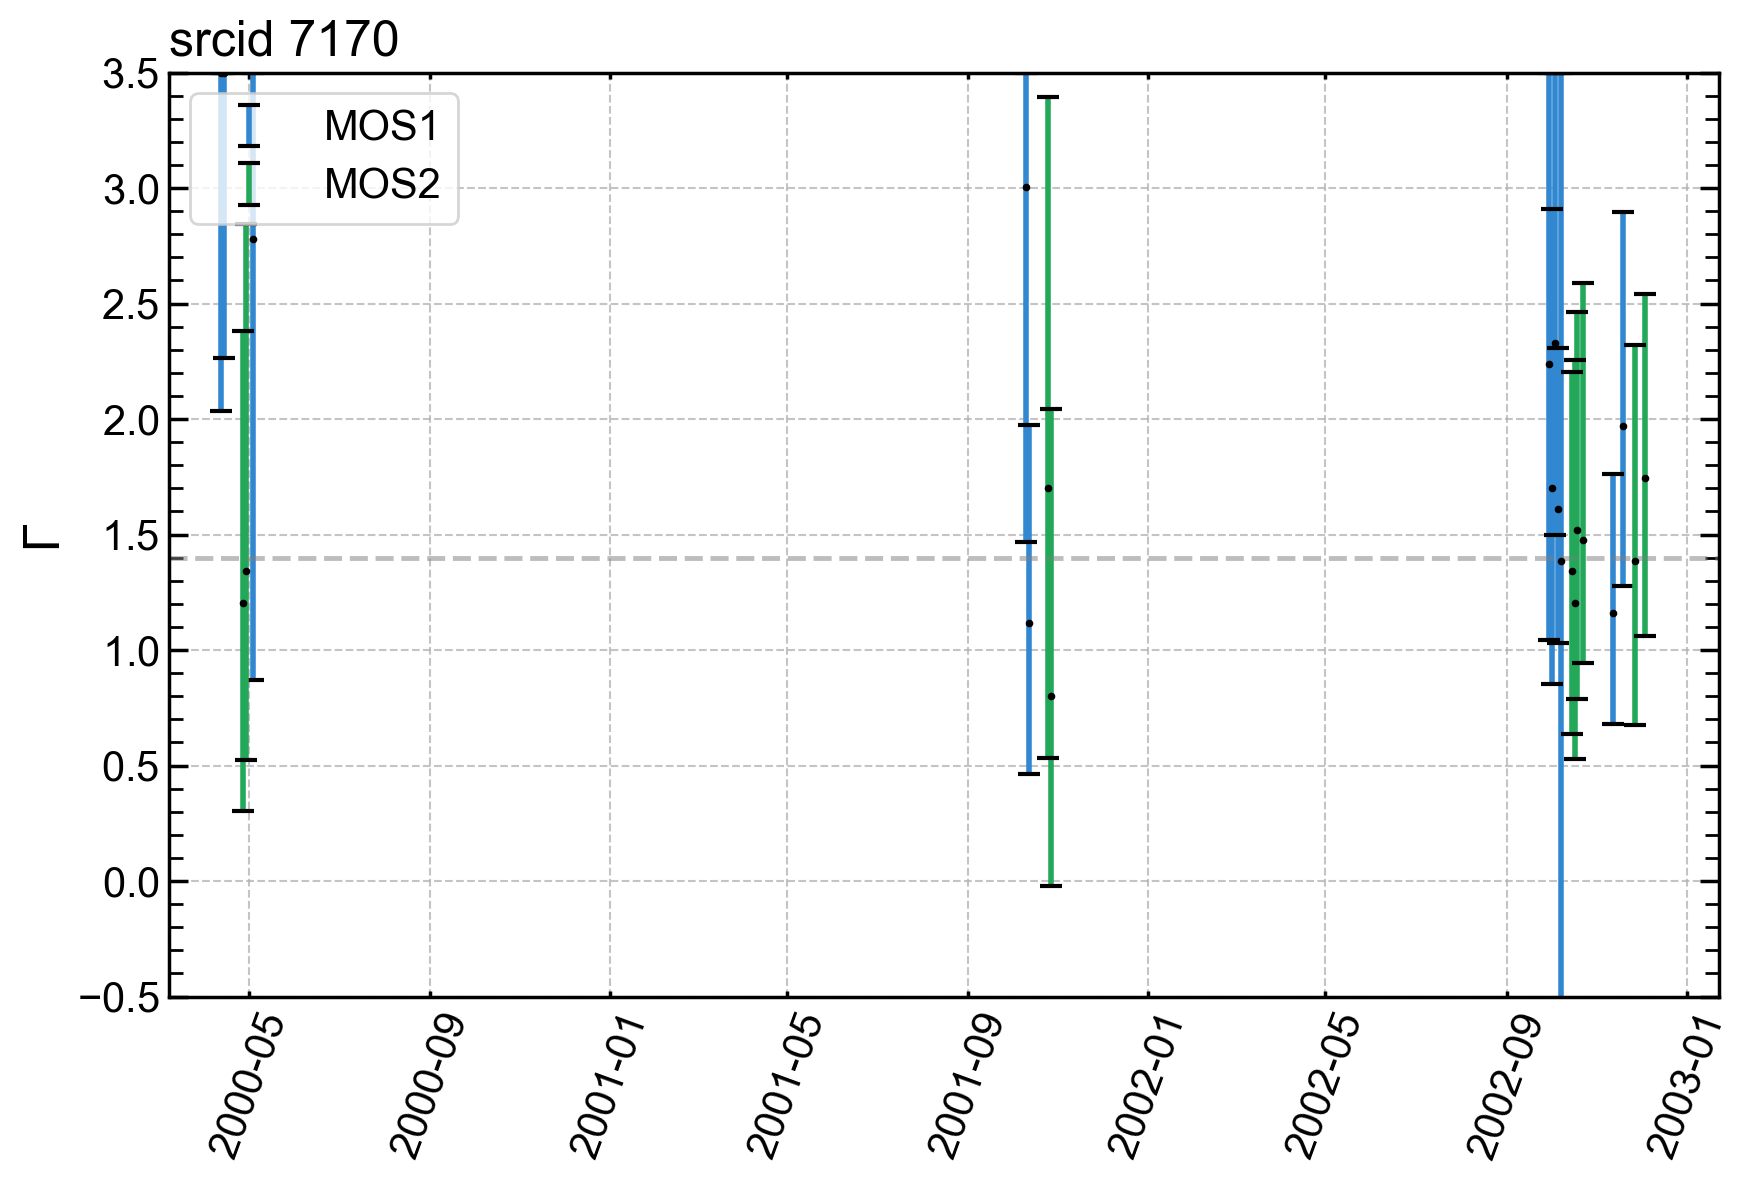

In [6]:
src_7170_PN_df = pd.read_csv('../data/source_201237001015035_7170_individual_M1_gap30_epicspeccombine_results.csv')
ax = plot_date_gamma(src_7170_PN_df, "MOS1", color='C0', alpha=1, pad=True, uplim=3.5)

src_7170_PN_addspec_df = pd.read_csv('../data/source_201237001015035_7170_individual_M2_gap30_epicspeccombine_results.csv')
plot_date_gamma(src_7170_PN_addspec_df, "MOS2", color='C2', alpha=1, ax=ax, uplim=3.5)

ax.set_title('srcid 7170', loc='left')

plt.show()

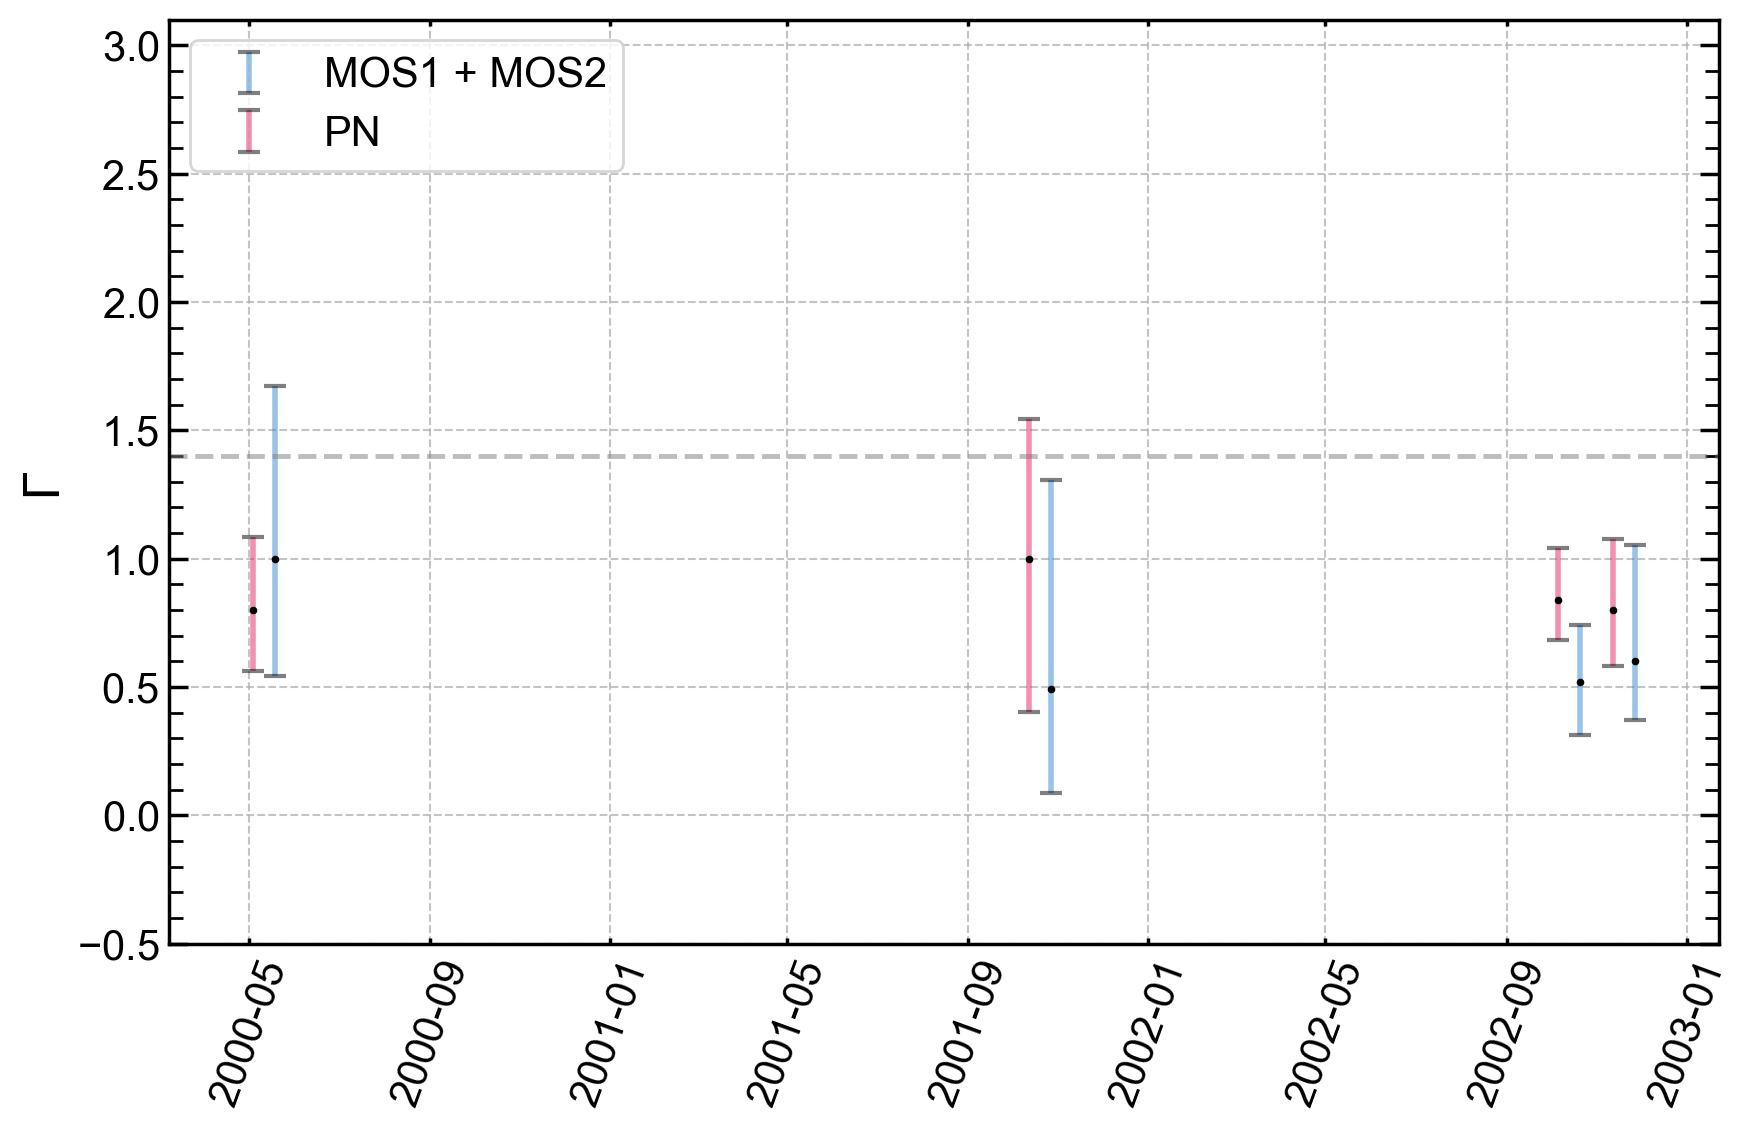

In [7]:
src_5359_df = pd.read_csv('../data/source_201237001010017_5359_clustered_MOS_gap30_results.csv')
ax = plot_date_gamma(src_5359_df, 'MOS1 + MOS2', color='C0')

src_5359_df = pd.read_csv('../data/source_201237001010017_5359_clustered_PN_gap30_results.csv')
ax = plot_date_gamma(src_5359_df, "PN", color='C1', ax=ax, pad=True)

# ax.set_title("srcid 5359 | PN and MOS1 + MOS2 clustered; ph*zph*zpo", loc='left')

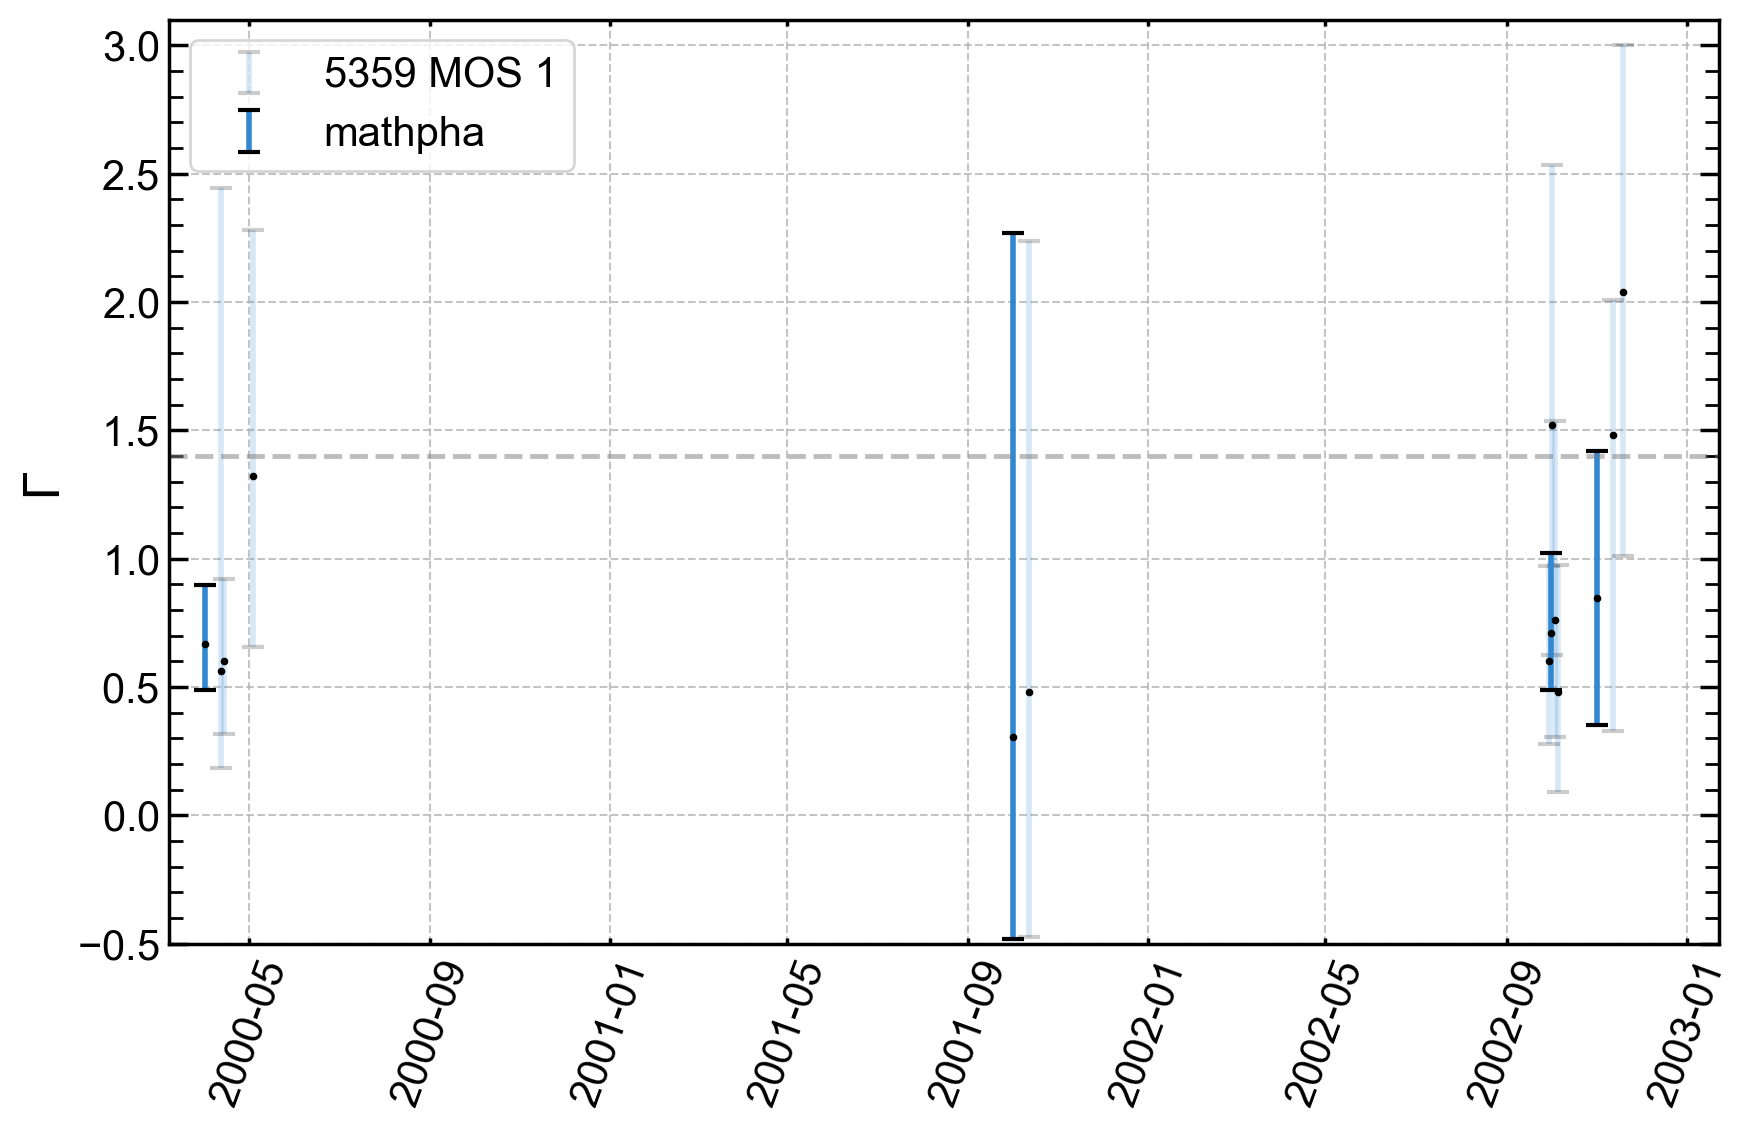

In [8]:
src_5359_M1_df = pd.read_csv('../data/source_201237001010017_5359_individual_M1_results.csv')
ax = plot_date_gamma(src_5359_M1_df, "5359 MOS 1", color='C0', alpha=0.2, pad=True)

src_5359_M1_addspec_df = pd.read_csv('../data/source_201237001010017_5359_clustered_M1_gap30_addspec_results.csv')
ax = plot_date_gamma(src_5359_M1_addspec_df, "mathpha", color='C0', alpha=1, ax=ax)

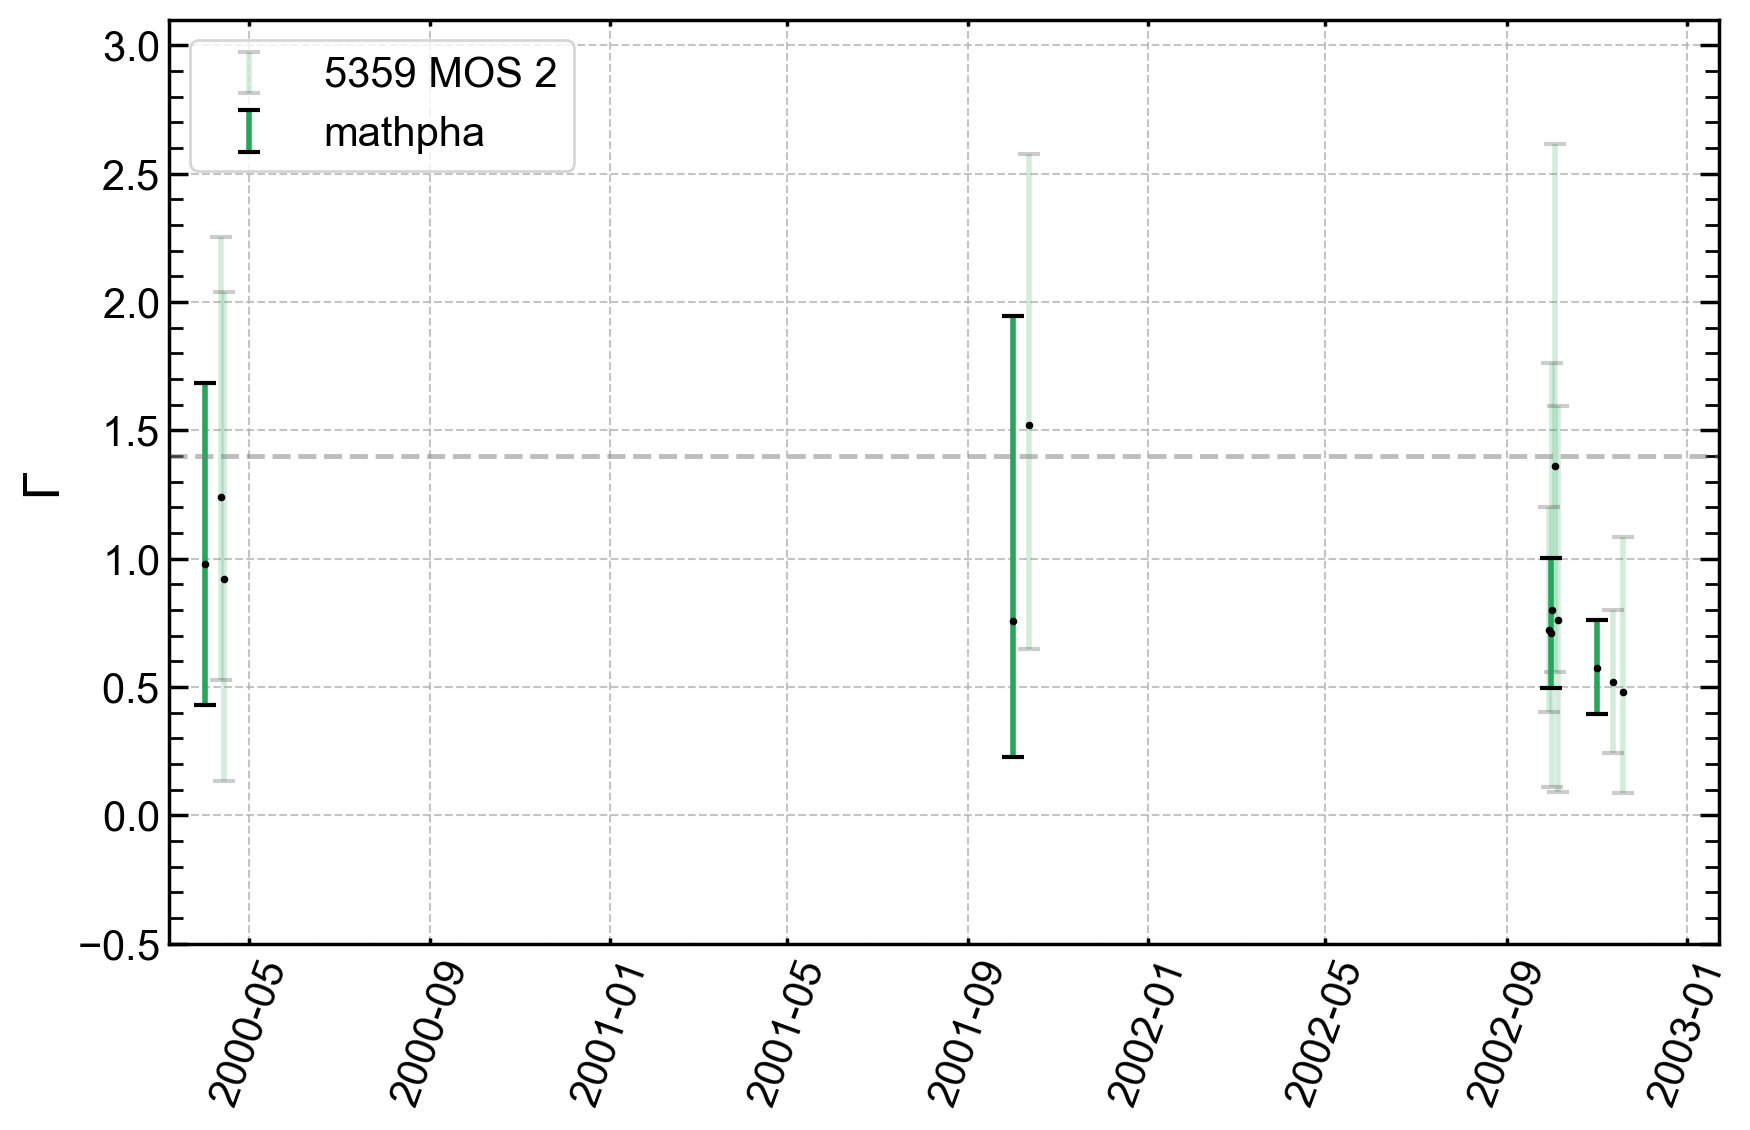

In [9]:
src_5359_M2_df = pd.read_csv('../data/source_201237001010017_5359_individual_M2_results.csv')
ax = plot_date_gamma(src_5359_M2_df, "5359 MOS 2", color='C2', alpha=0.2, pad=True)

src_5359_M2_addspec_df = pd.read_csv('../data/source_201237001010017_5359_clustered_M2_gap30_addspec_results.csv')
ax = plot_date_gamma(src_5359_M2_addspec_df, "mathpha", color='C2', alpha=1, ax=ax)

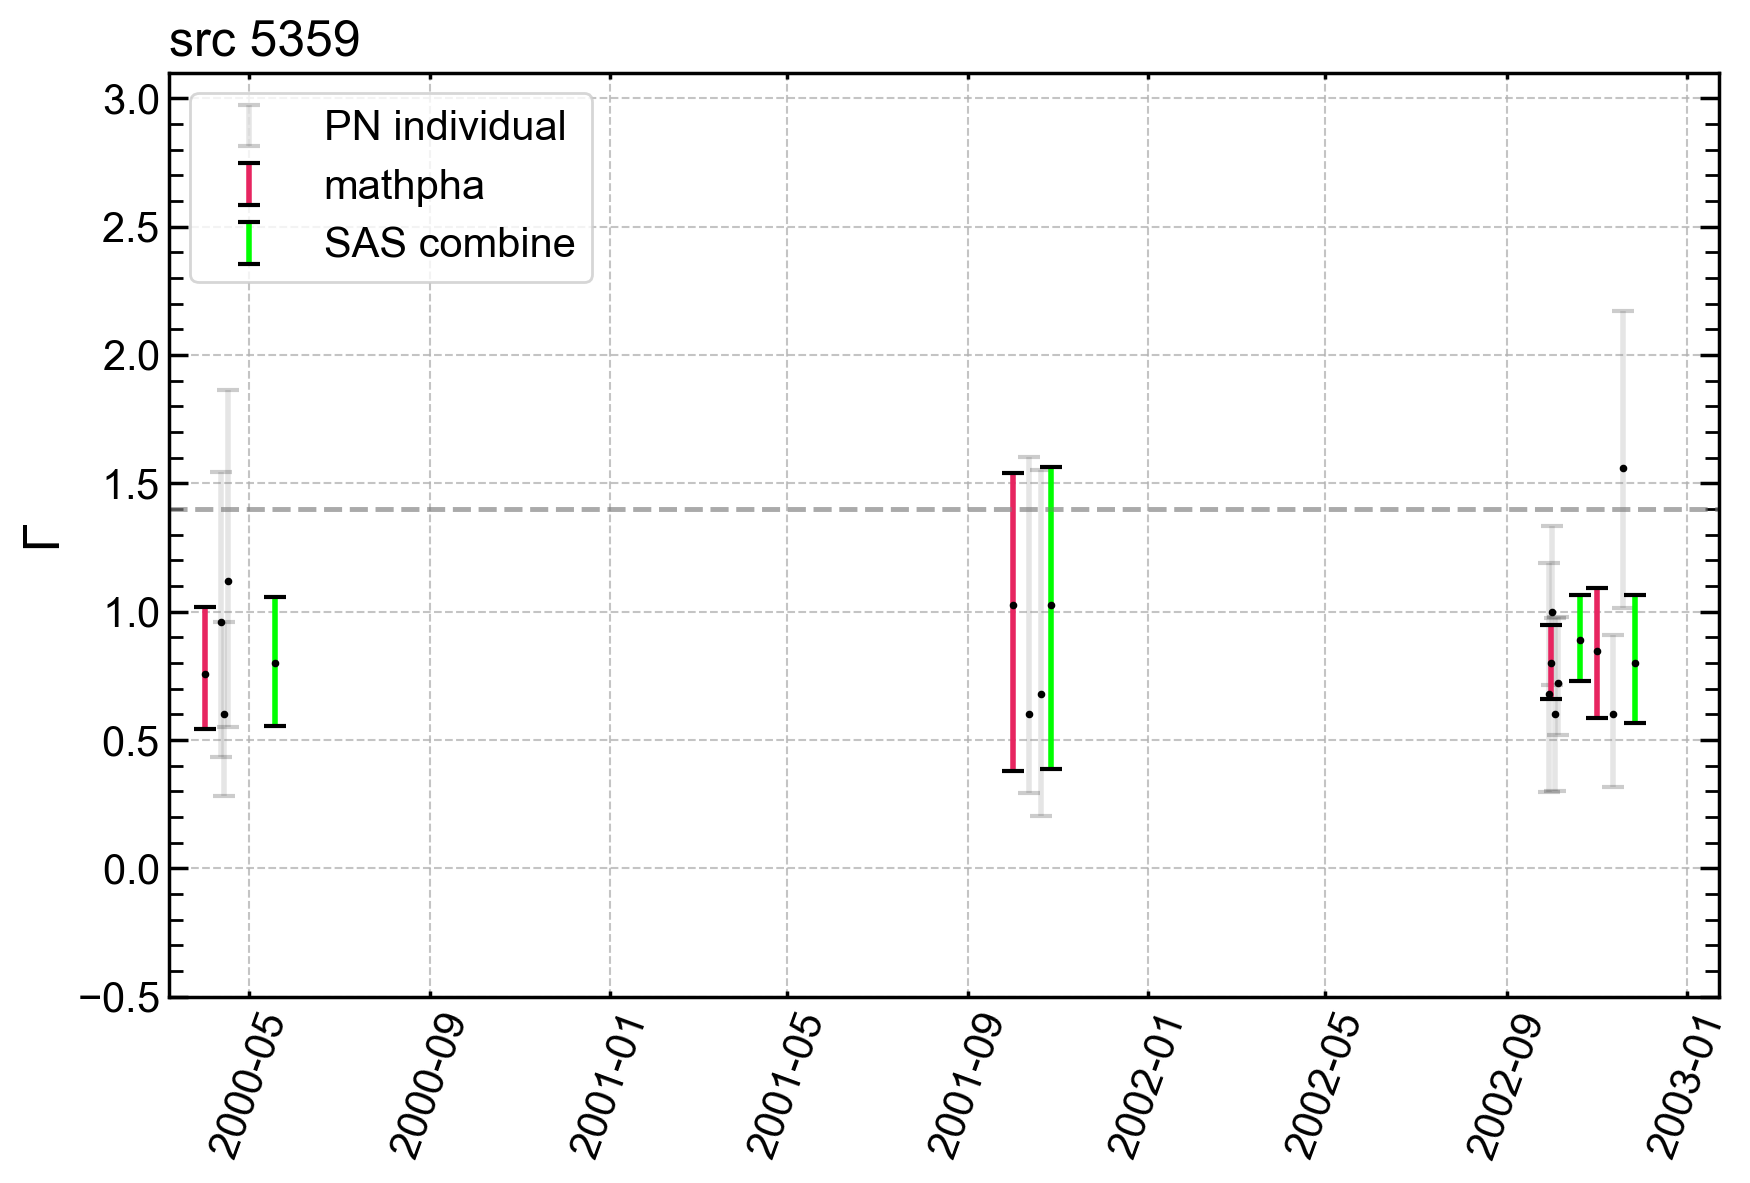

In [10]:
src_5359_PN_df = pd.read_csv('../data/source_201237001010017_5359_individual_PN_results.csv')
ax = plot_date_gamma(src_5359_PN_df, "PN individual", color='gray', alpha=0.2, pad=True)

src_5359_PN_addspec_df = pd.read_csv('../data/source_201237001010017_5359_clustered_PN_gap30_addspec_results.csv')
ax = plot_date_gamma(src_5359_PN_addspec_df, "mathpha", color='C1', alpha=1, ax=ax)

src_5359_PN_sascombine_df = pd.read_csv('../data/source_201237001010017_5359_clustered_PN_gap30_epicspeccombine_results.csv')
ax = plot_date_gamma(src_5359_PN_sascombine_df, "SAS combine", color='lime', alpha=1, ax=ax)

ax.set_title('src 5359', loc='left')
plt.show()

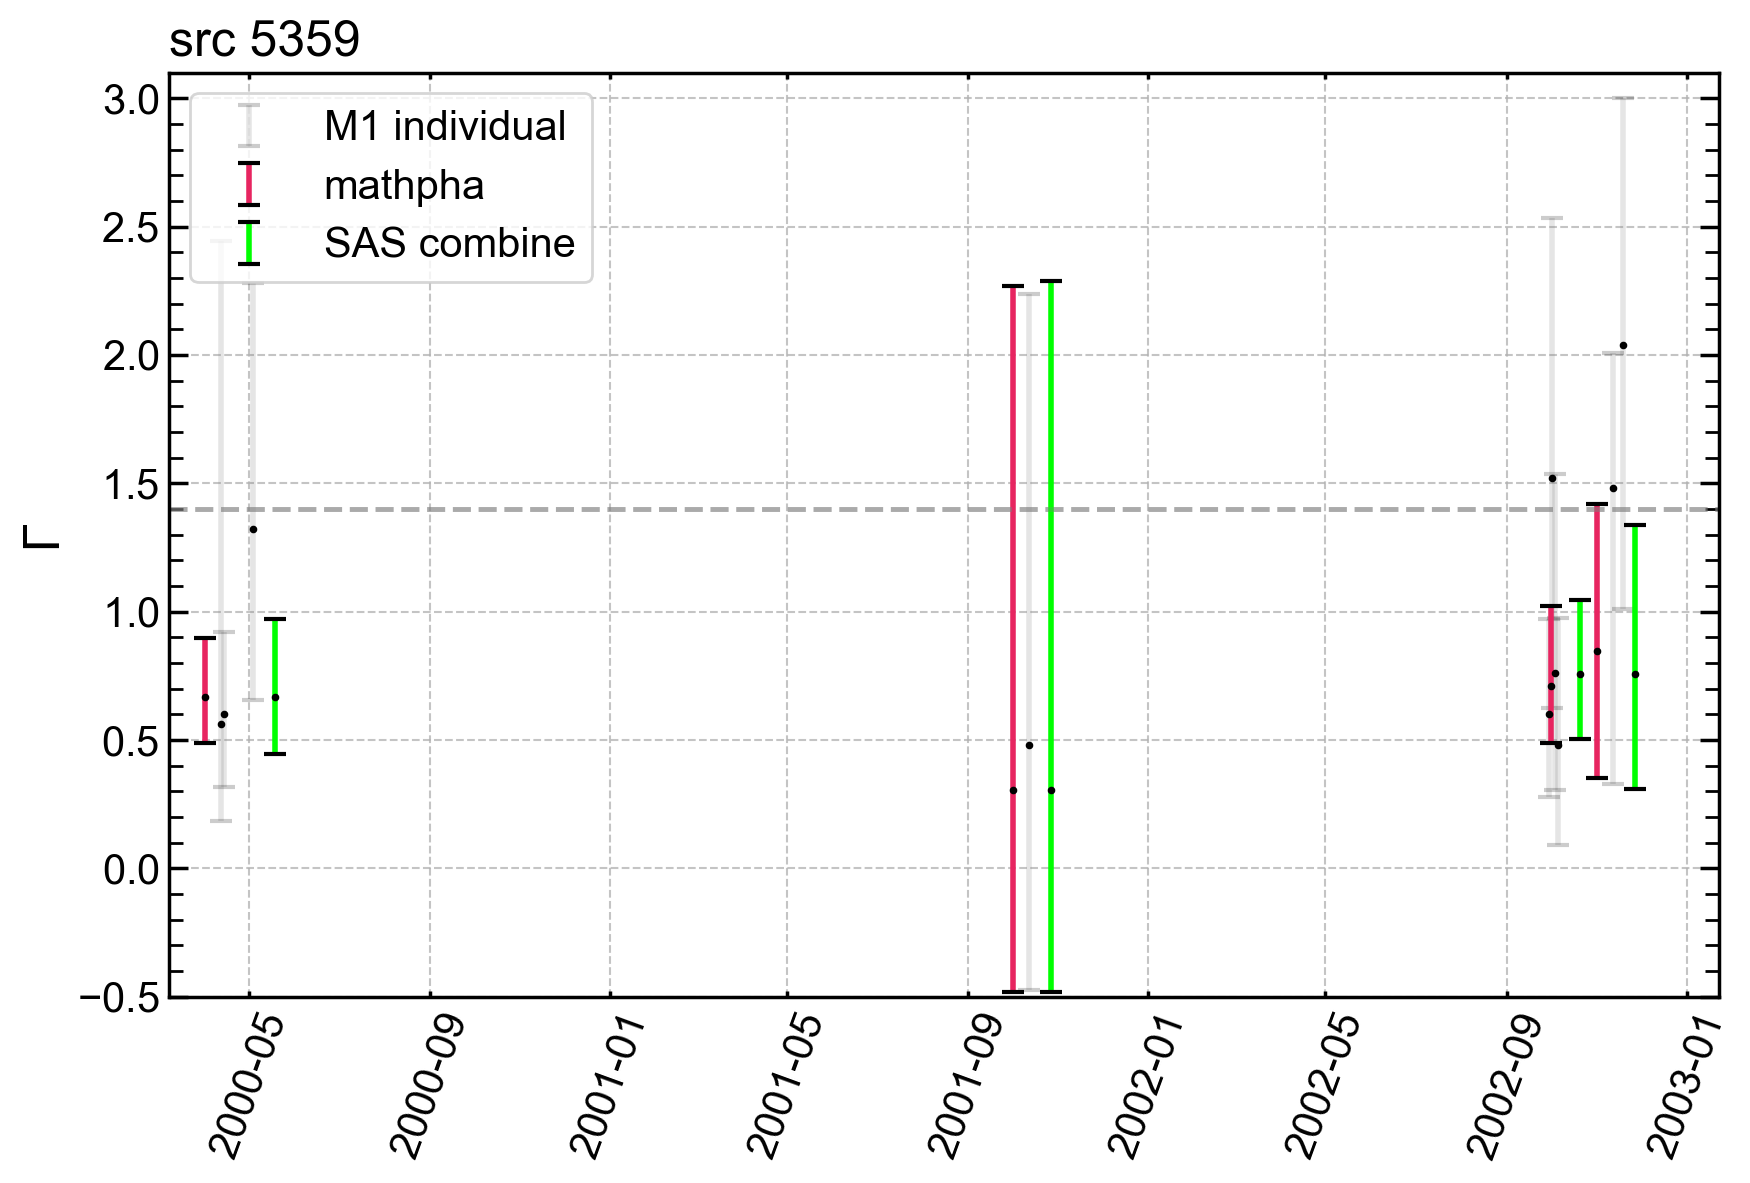

In [11]:
src_5359_M1_df = pd.read_csv('../data/source_201237001010017_5359_individual_M1_results.csv')
ax = plot_date_gamma(src_5359_M1_df, "M1 individual", color='gray', alpha=0.2, pad=True)

src_5359_M1_addspec_df = pd.read_csv('../data/source_201237001010017_5359_clustered_M1_gap30_addspec_results.csv')
ax = plot_date_gamma(src_5359_M1_addspec_df, "mathpha", color='C1', alpha=1, ax=ax)

src_5359_M1_sascombine_df = pd.read_csv('../data/source_201237001010017_5359_clustered_M1_gap30_epicspeccombine_results.csv')
ax = plot_date_gamma(src_5359_M1_sascombine_df, "SAS combine", color='lime', alpha=1, ax=ax)

ax.set_title('src 5359', loc='left')
plt.show()

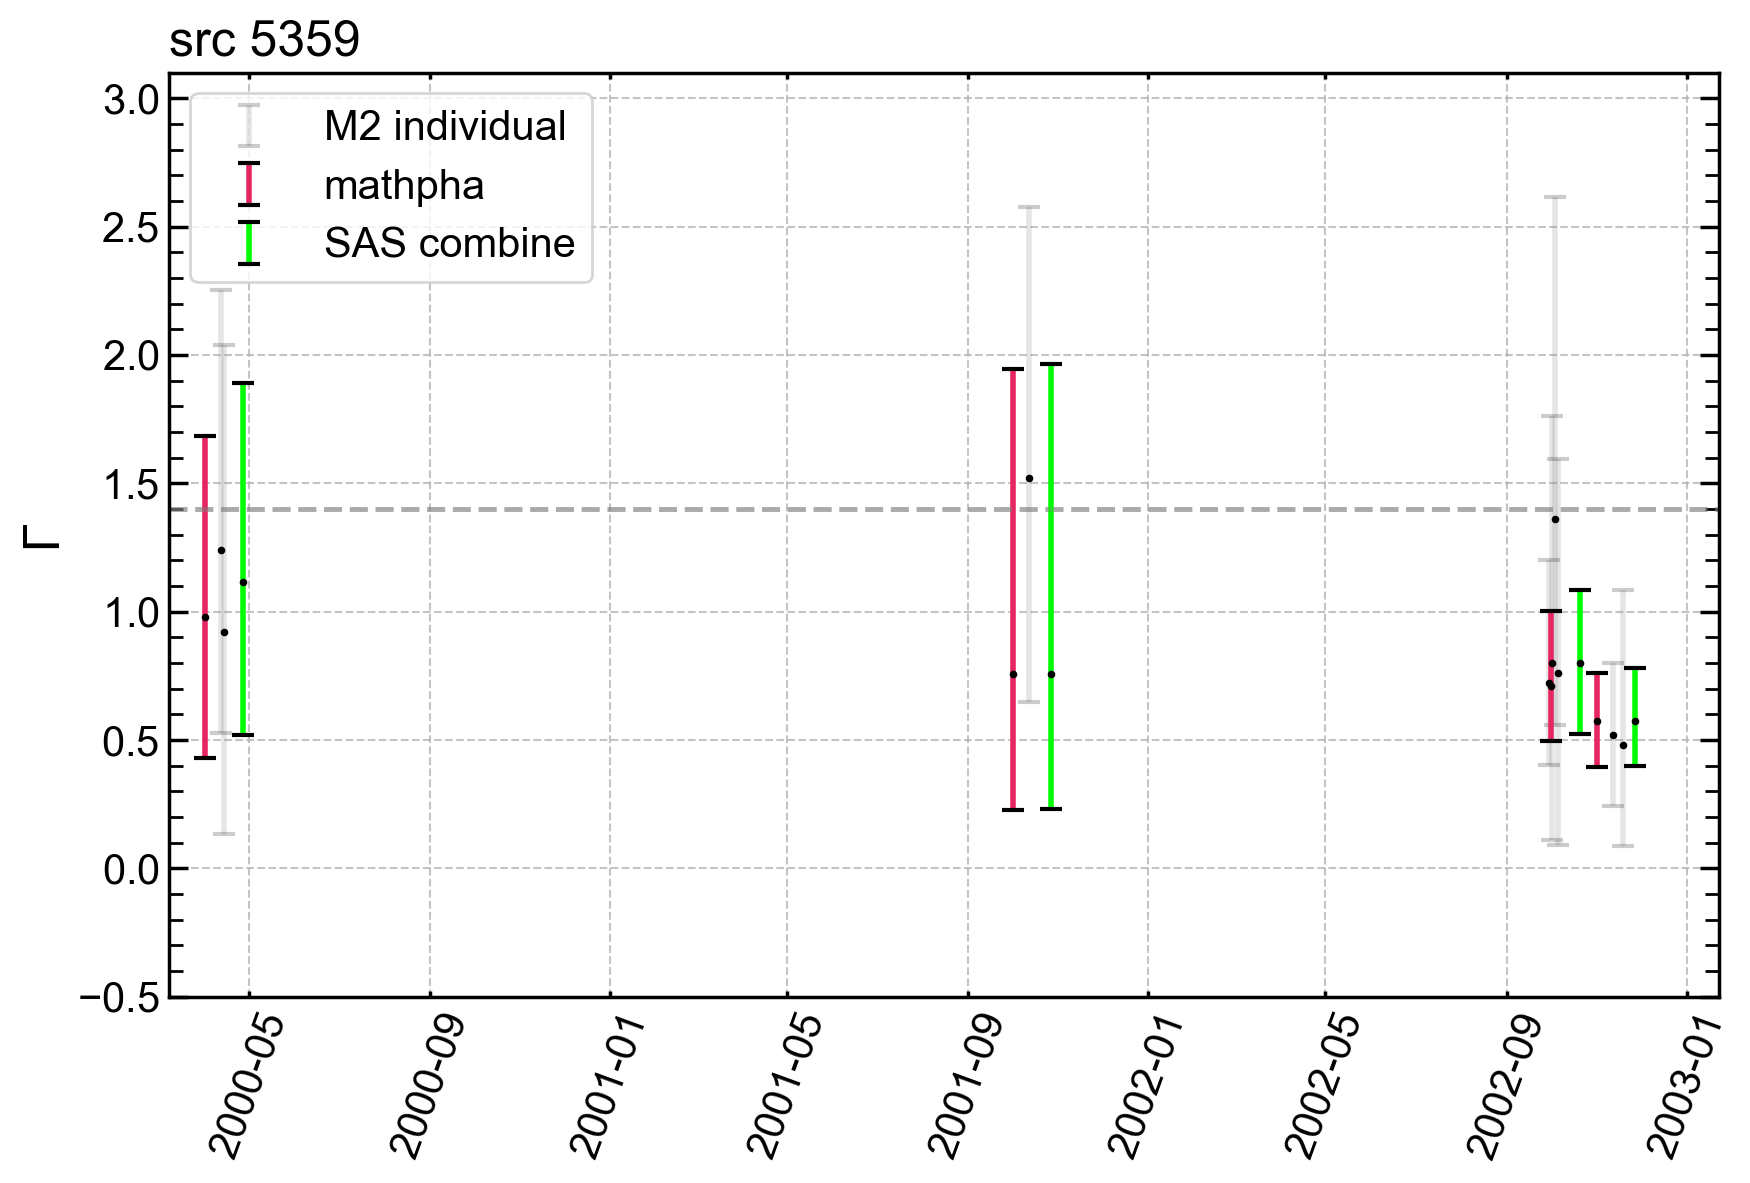

In [12]:
src_5359_M2_df = pd.read_csv('../data/source_201237001010017_5359_individual_M2_results.csv')
ax = plot_date_gamma(src_5359_M2_df, "M2 individual", color='gray', alpha=0.2, pad=True)

src_5359_M2_addspec_df = pd.read_csv('../data/source_201237001010017_5359_clustered_M2_gap30_addspec_results.csv')
ax = plot_date_gamma(src_5359_M2_addspec_df, "mathpha", color='C1', alpha=1, ax=ax)

src_5359_M2_sascombine_df = pd.read_csv('../data/source_201237001010017_5359_clustered_M2_gap30_epicspeccombine_results.csv')
ax = plot_date_gamma(src_5359_M2_sascombine_df, "SAS combine", color='lime', alpha=1, ax=ax)

ax.set_title('src 5359', loc='left')
plt.show()

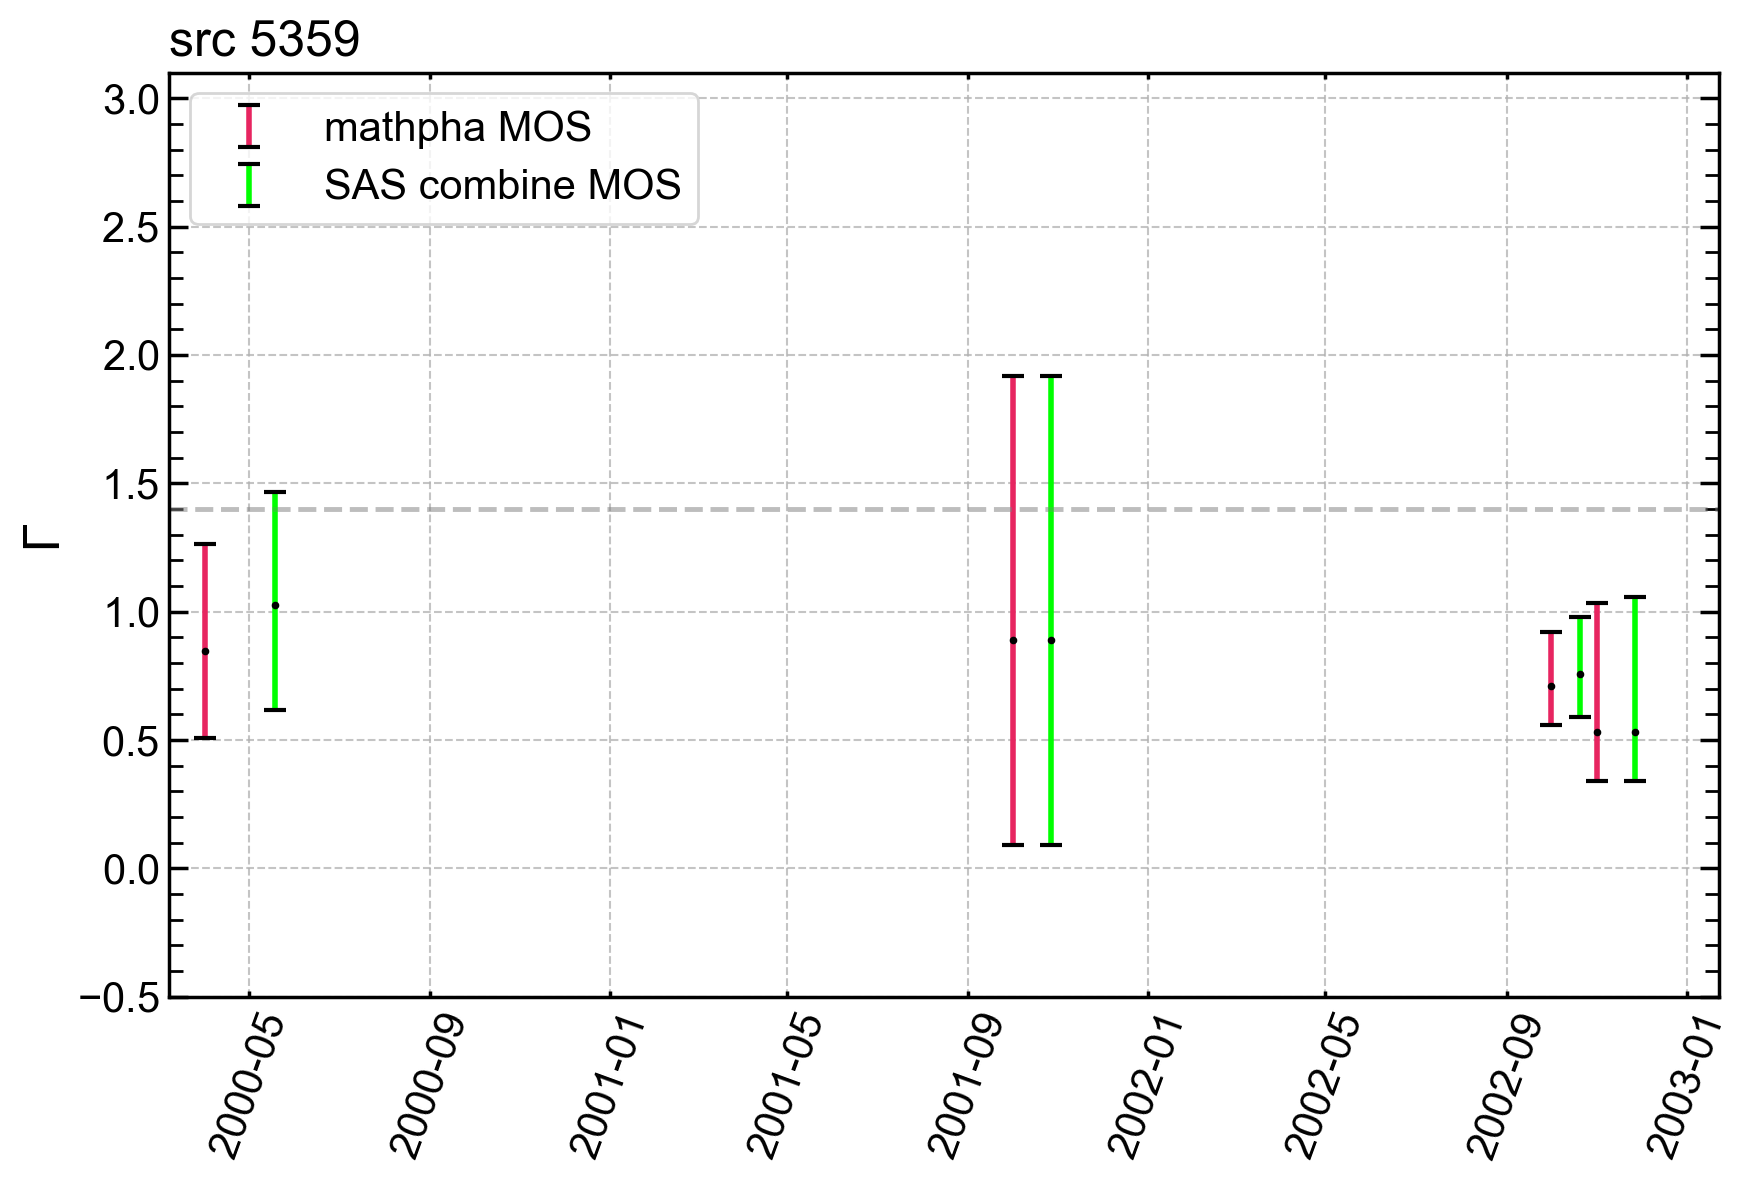

In [13]:
src_5359_MOS_addspec_df = pd.read_csv('../data/source_201237001010017_5359_clustered_MOS_gap30_addspec_results.csv')
ax = plot_date_gamma(src_5359_MOS_addspec_df, "mathpha MOS", color='C1', alpha=1)

src_5359_MOS_sascombine_df = pd.read_csv('../data/source_201237001010017_5359_clustered_MOS_gap30_epicspeccombine_results.csv')
ax = plot_date_gamma(src_5359_MOS_sascombine_df, "SAS combine MOS", color='lime', alpha=1, ax=ax)

ax.set_title('src 5359', loc='left')
plt.show()

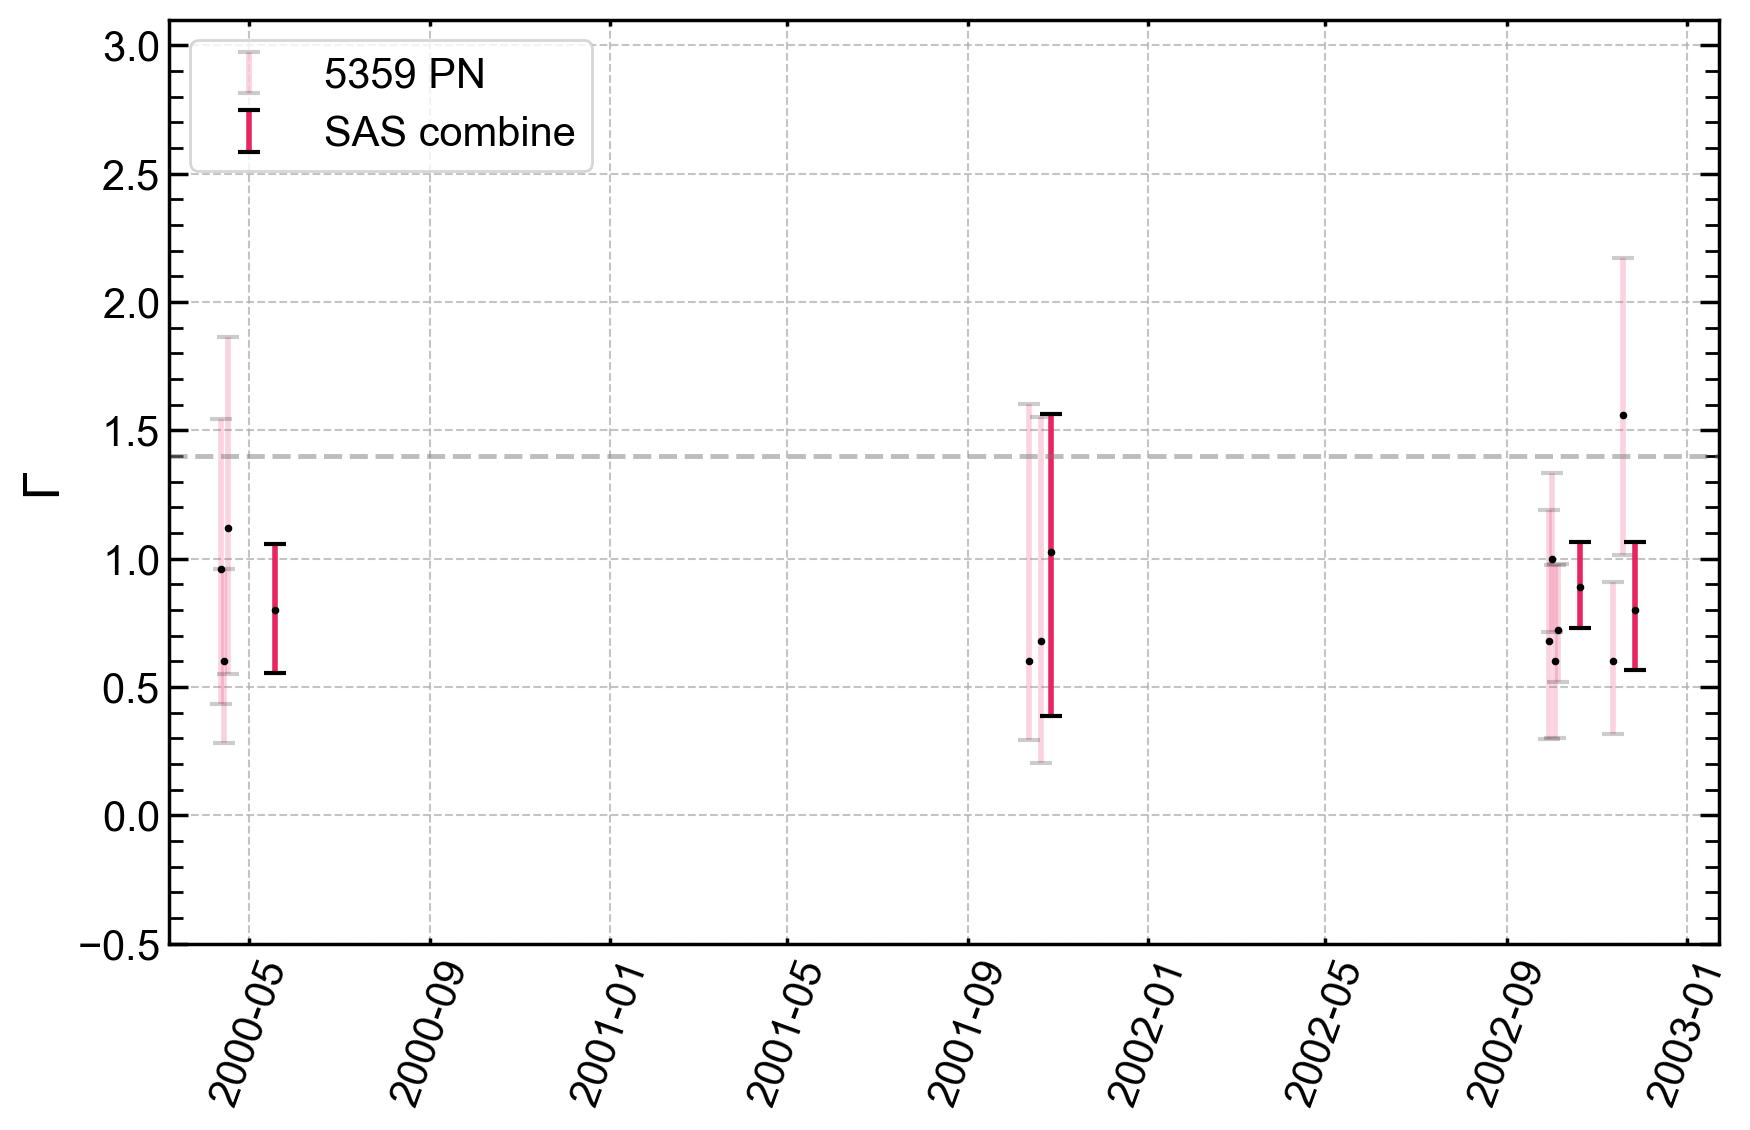

In [14]:
src_5359_PN_df = pd.read_csv('../data/source_201237001010017_5359_individual_PN_results.csv')
ax = plot_date_gamma(src_5359_PN_df, "5359 PN", color='C1', alpha=0.2, pad=True)

src_5359_PN_addspec_df = pd.read_csv('../data/source_201237001010017_5359_clustered_PN_gap30_epicspeccombine_results.csv')
ax = plot_date_gamma(src_5359_PN_addspec_df, "SAS combine", color='C1', alpha=1, ax=ax)

<Axes: ylabel='Г'>

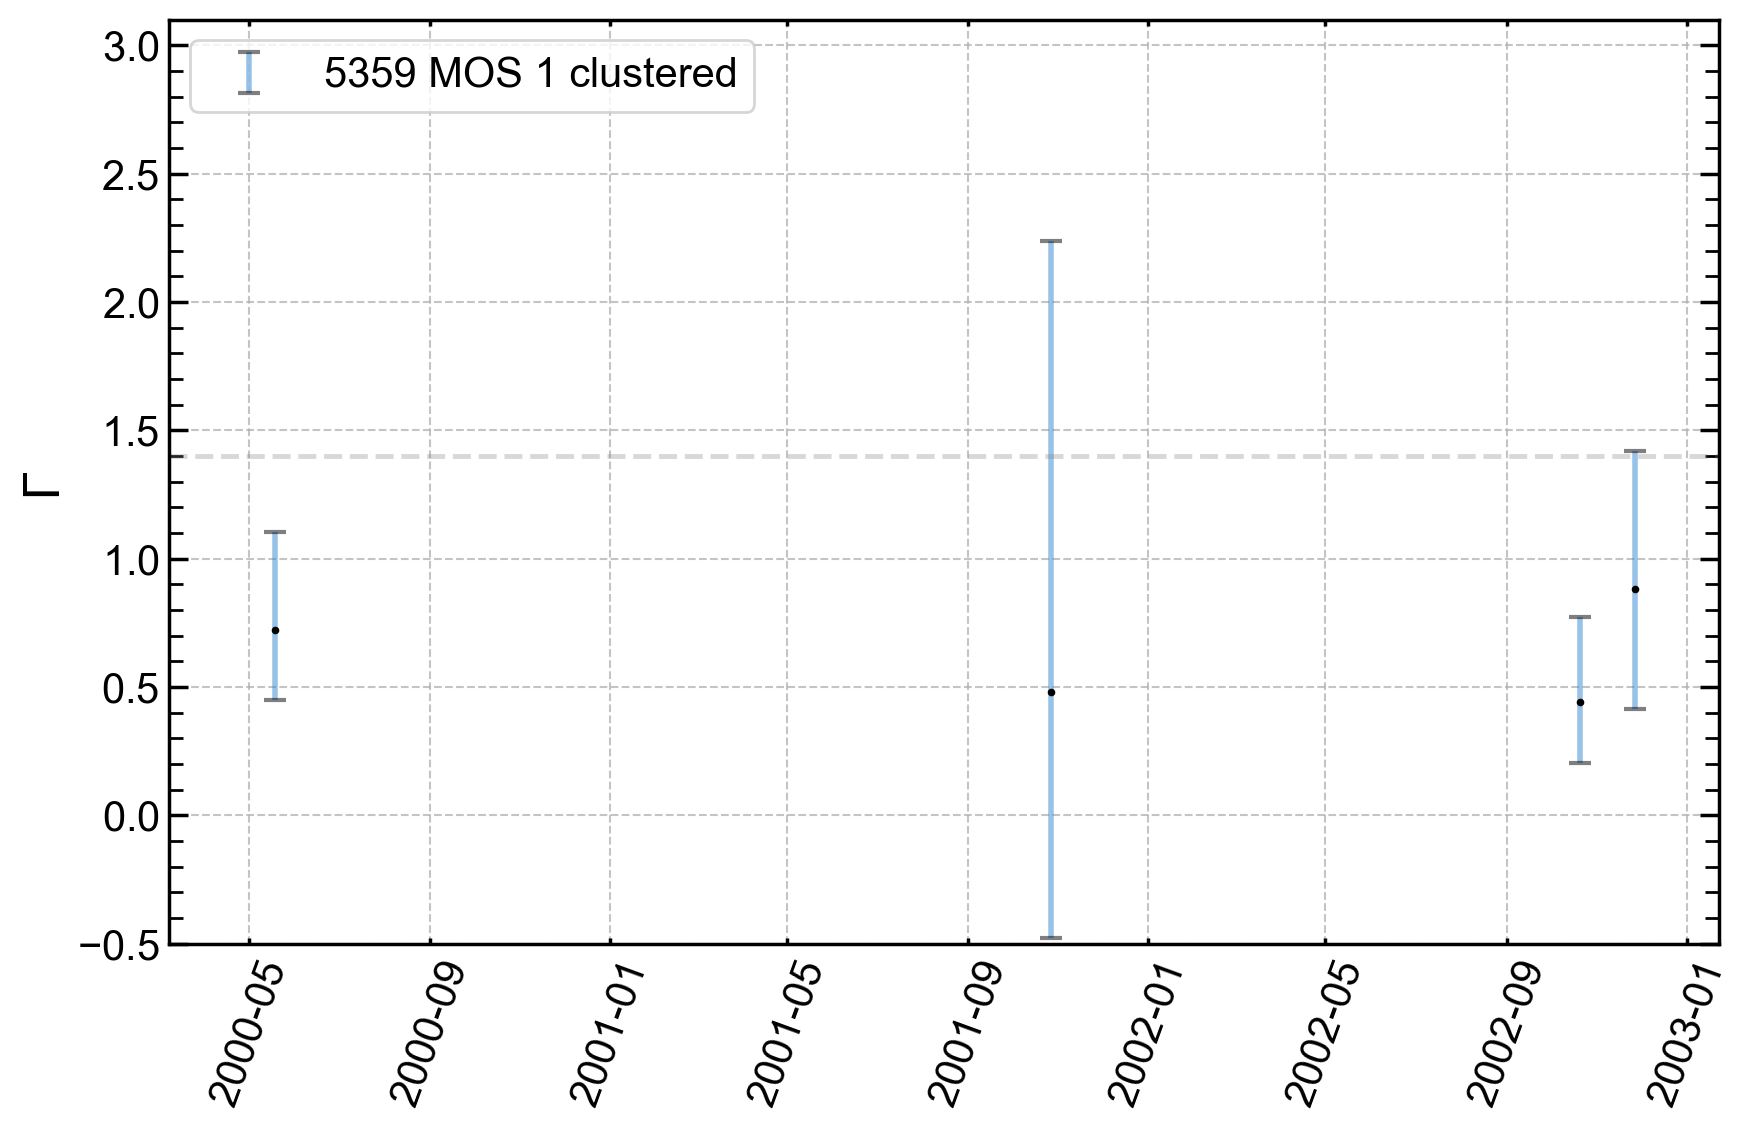

In [15]:
src_5359_M1_cluster_df = pd.read_csv('../data/source_201237001010017_5359_clustered_M1_gap30_results.csv')

plot_date_gamma(src_5359_M1_cluster_df, "5359 MOS 1 clustered", color='C0')

<Axes: ylabel='Г'>

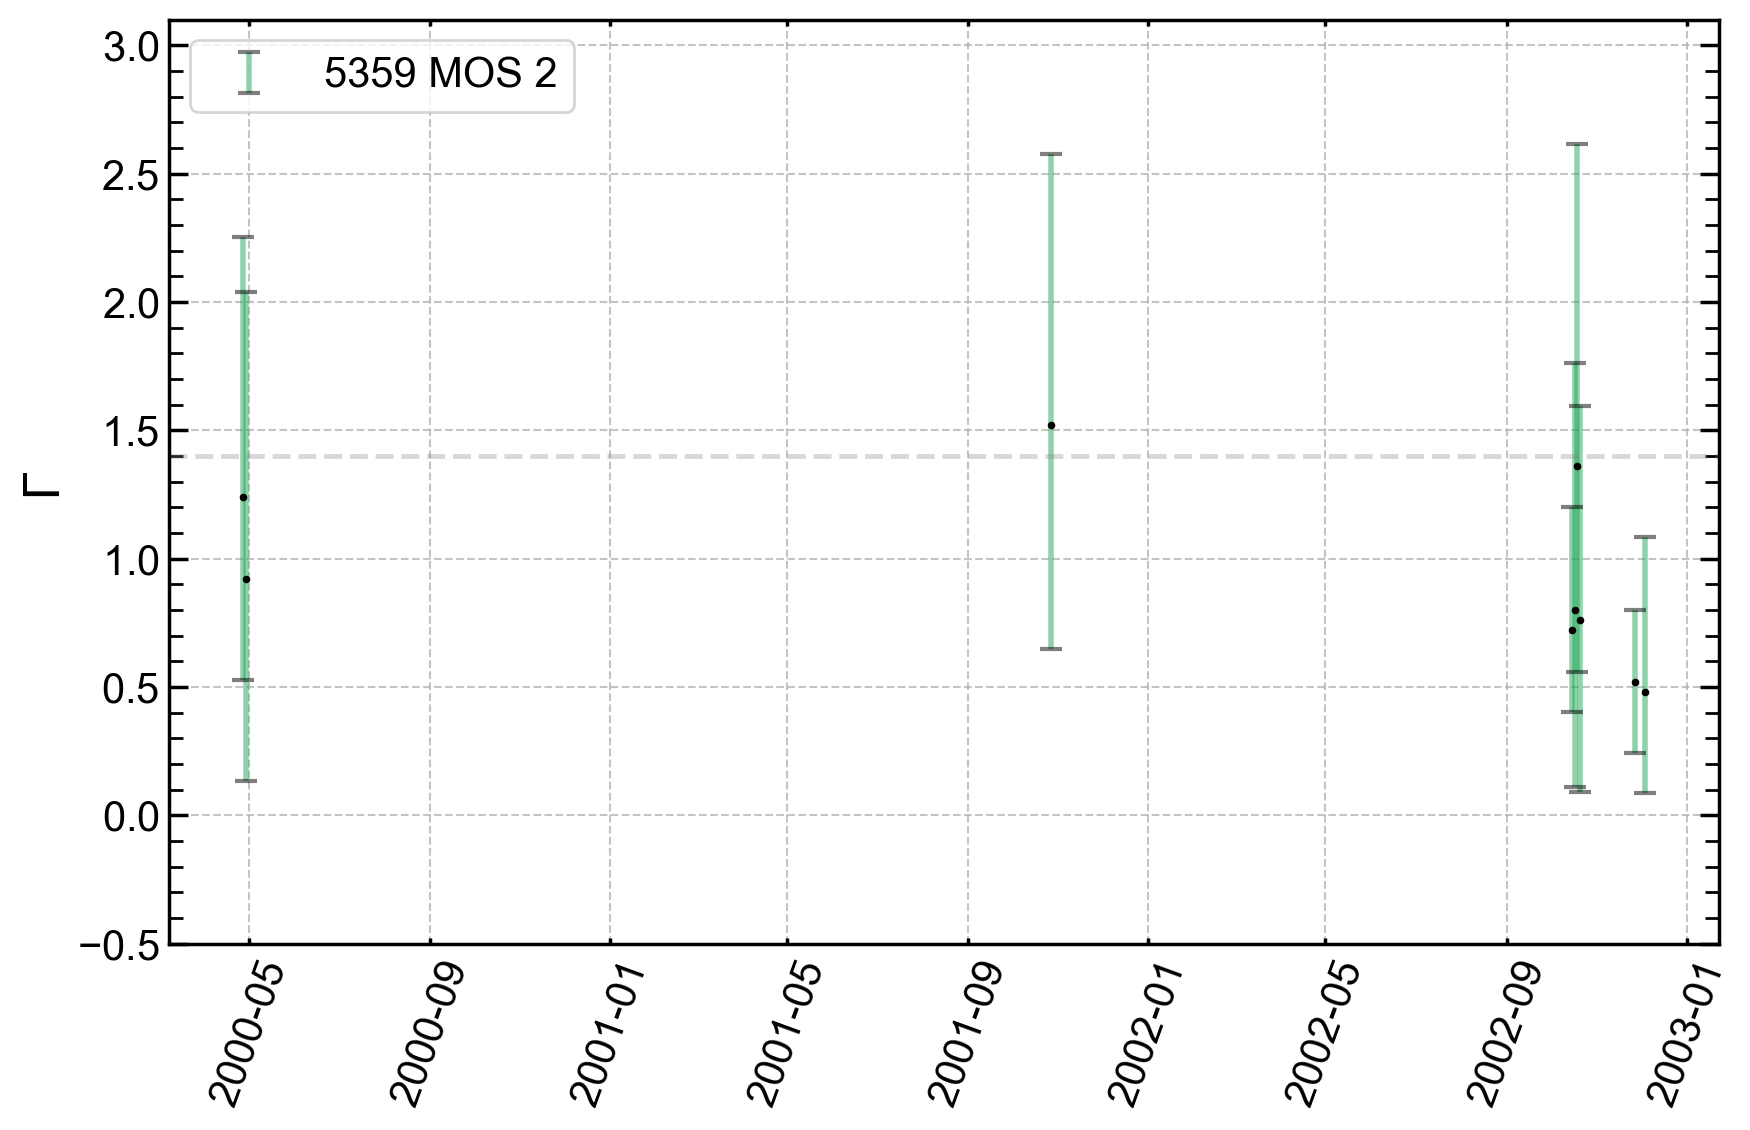

In [16]:
src_5359_M2_df = pd.read_csv('../data/source_201237001010017_5359_individual_M2_results.csv')

plot_date_gamma(src_5359_M2_df, "5359 MOS 2", color='C2')

<Axes: ylabel='Г'>

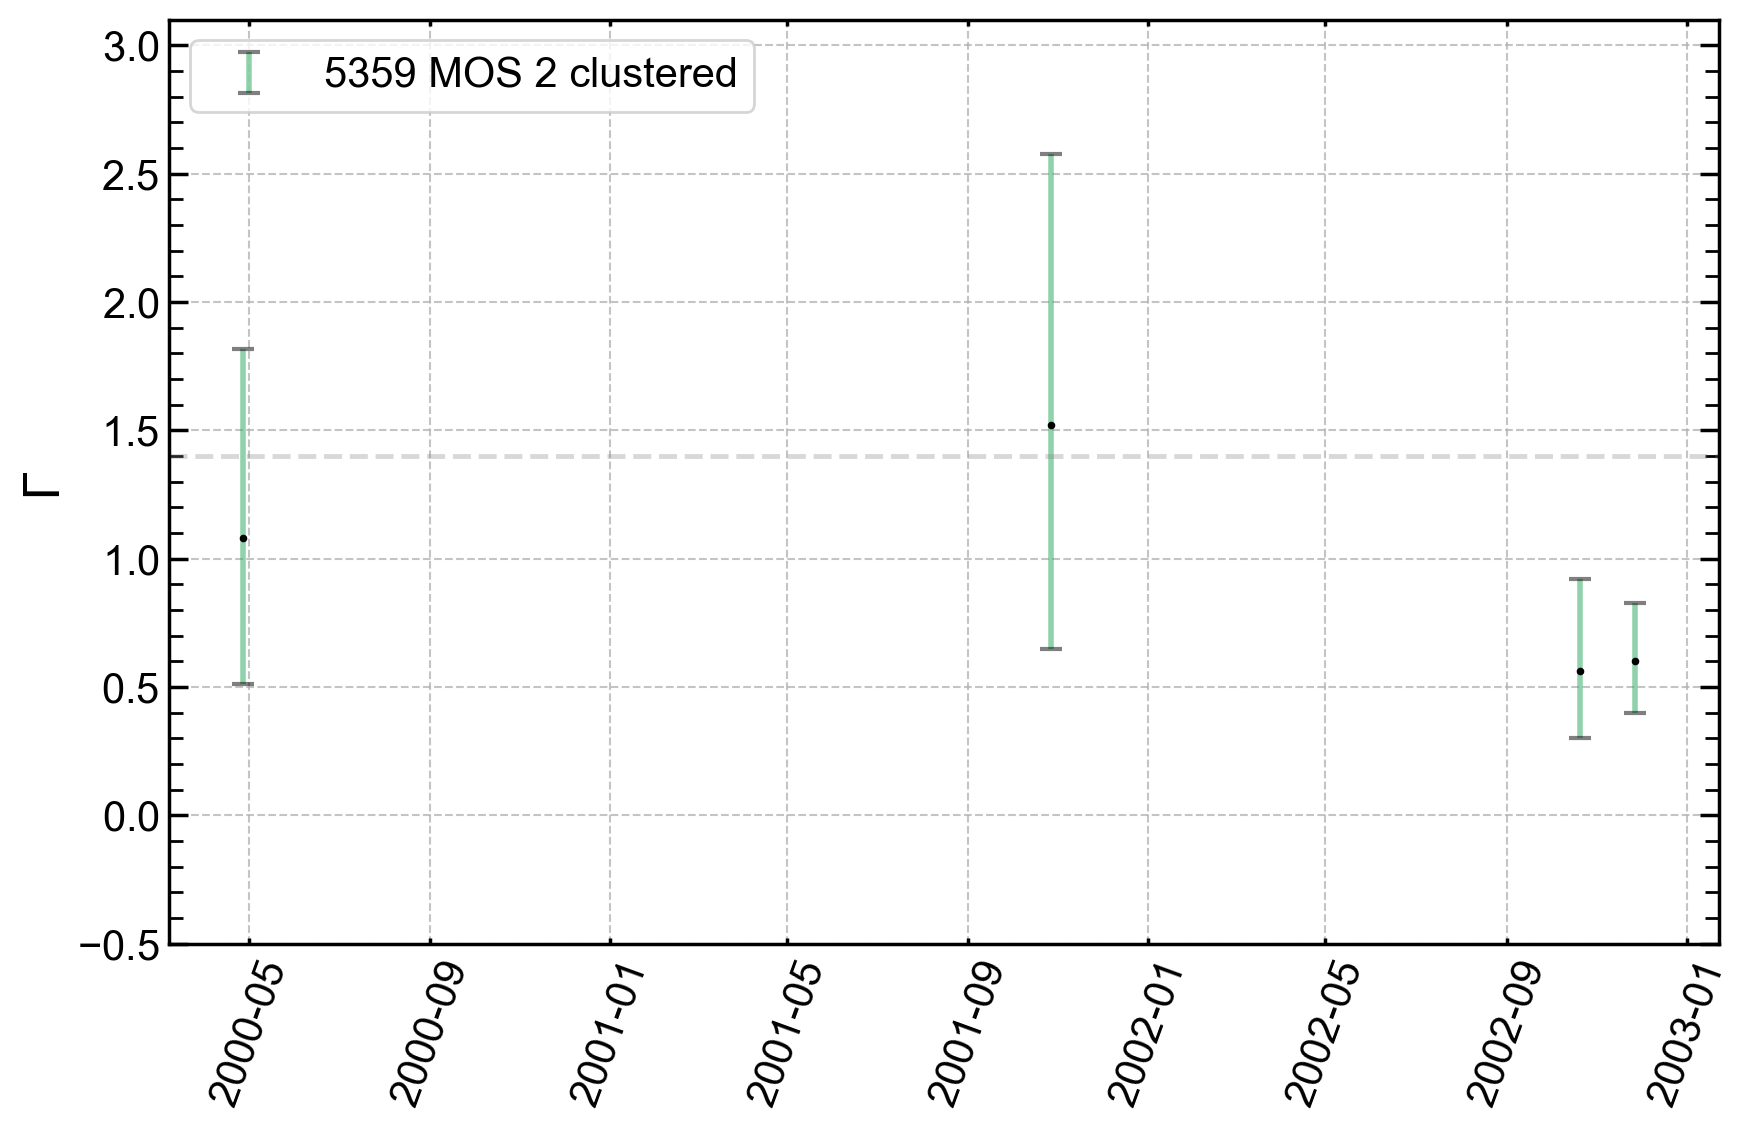

In [17]:
src_5359_M2_cluster_df = pd.read_csv('../data/source_201237001010017_5359_clustered_M2_gap30_results.csv')

plot_date_gamma(src_5359_M2_cluster_df, "5359 MOS 2 clustered", color='C2')

<Axes: ylabel='Г'>

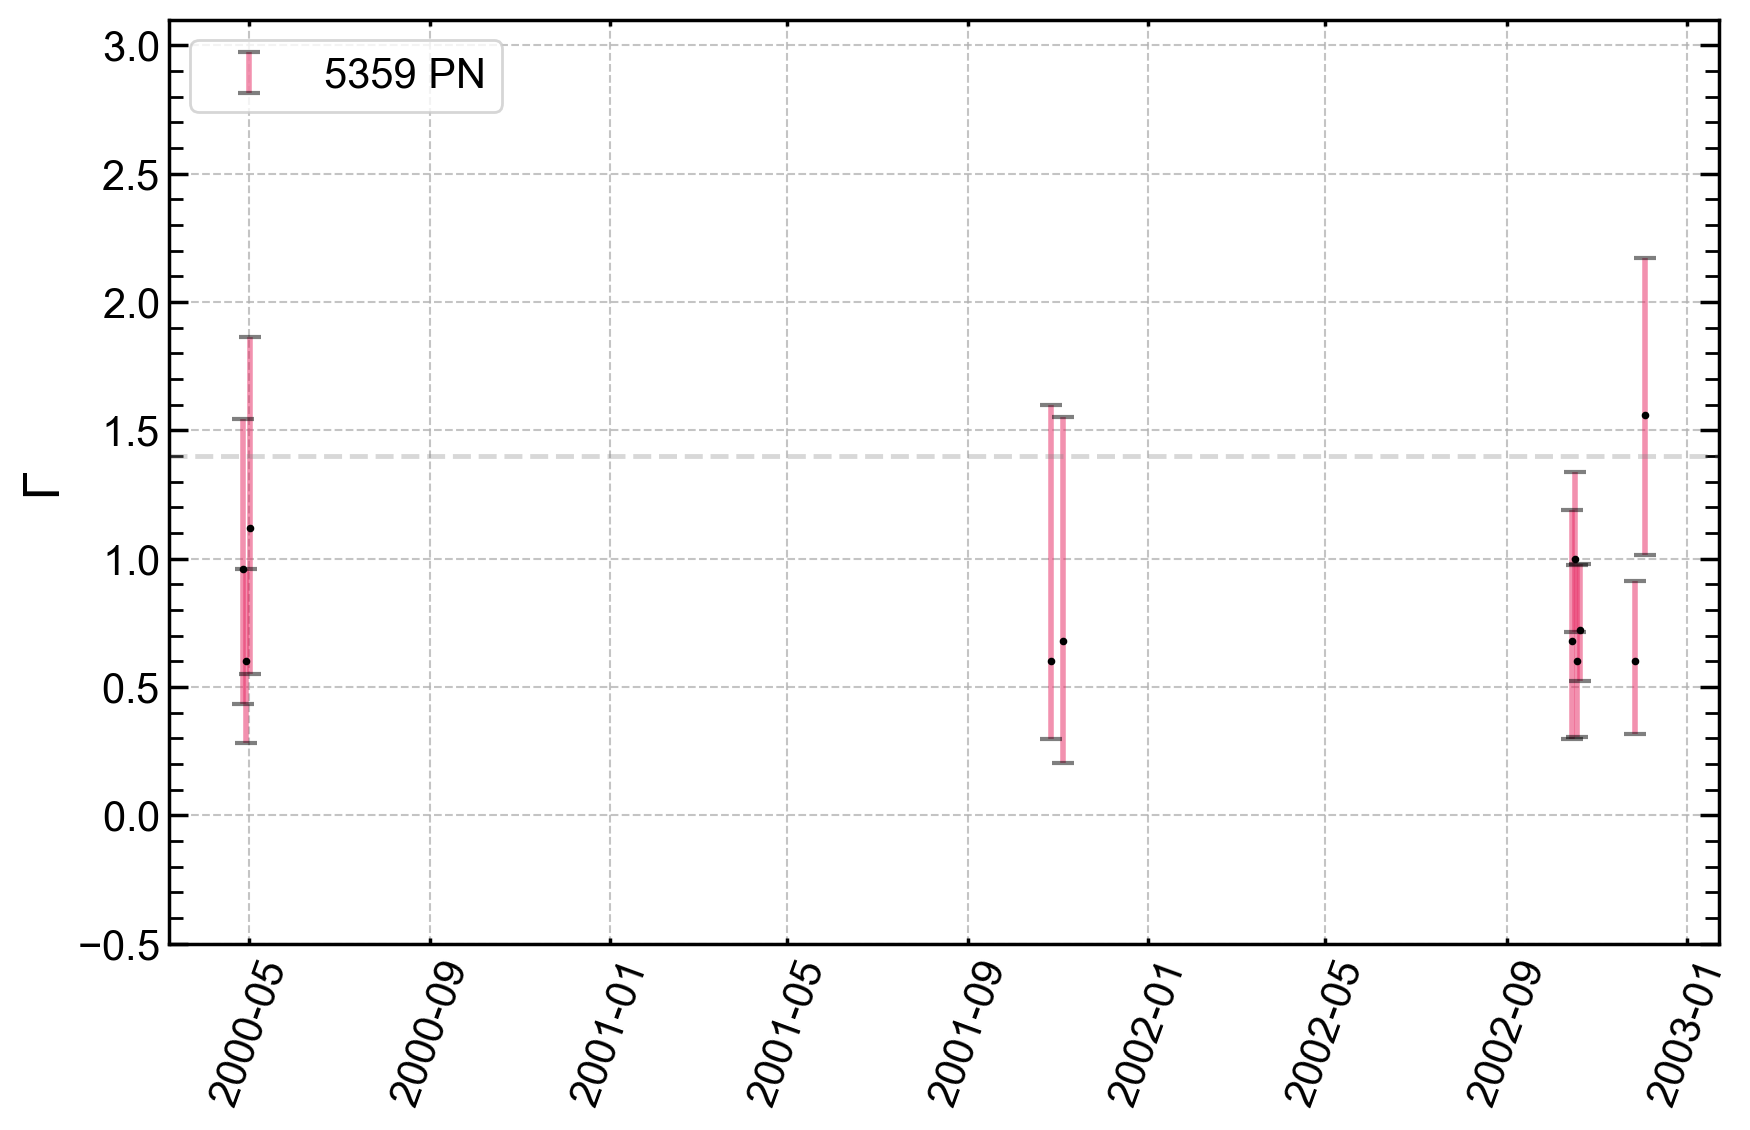

In [18]:
src_5359_df = pd.read_csv('../data/source_201237001010017_5359_results.csv')

plot_date_gamma(src_5359_df, "5359 PN", color='C1')

<Axes: ylabel='Г'>

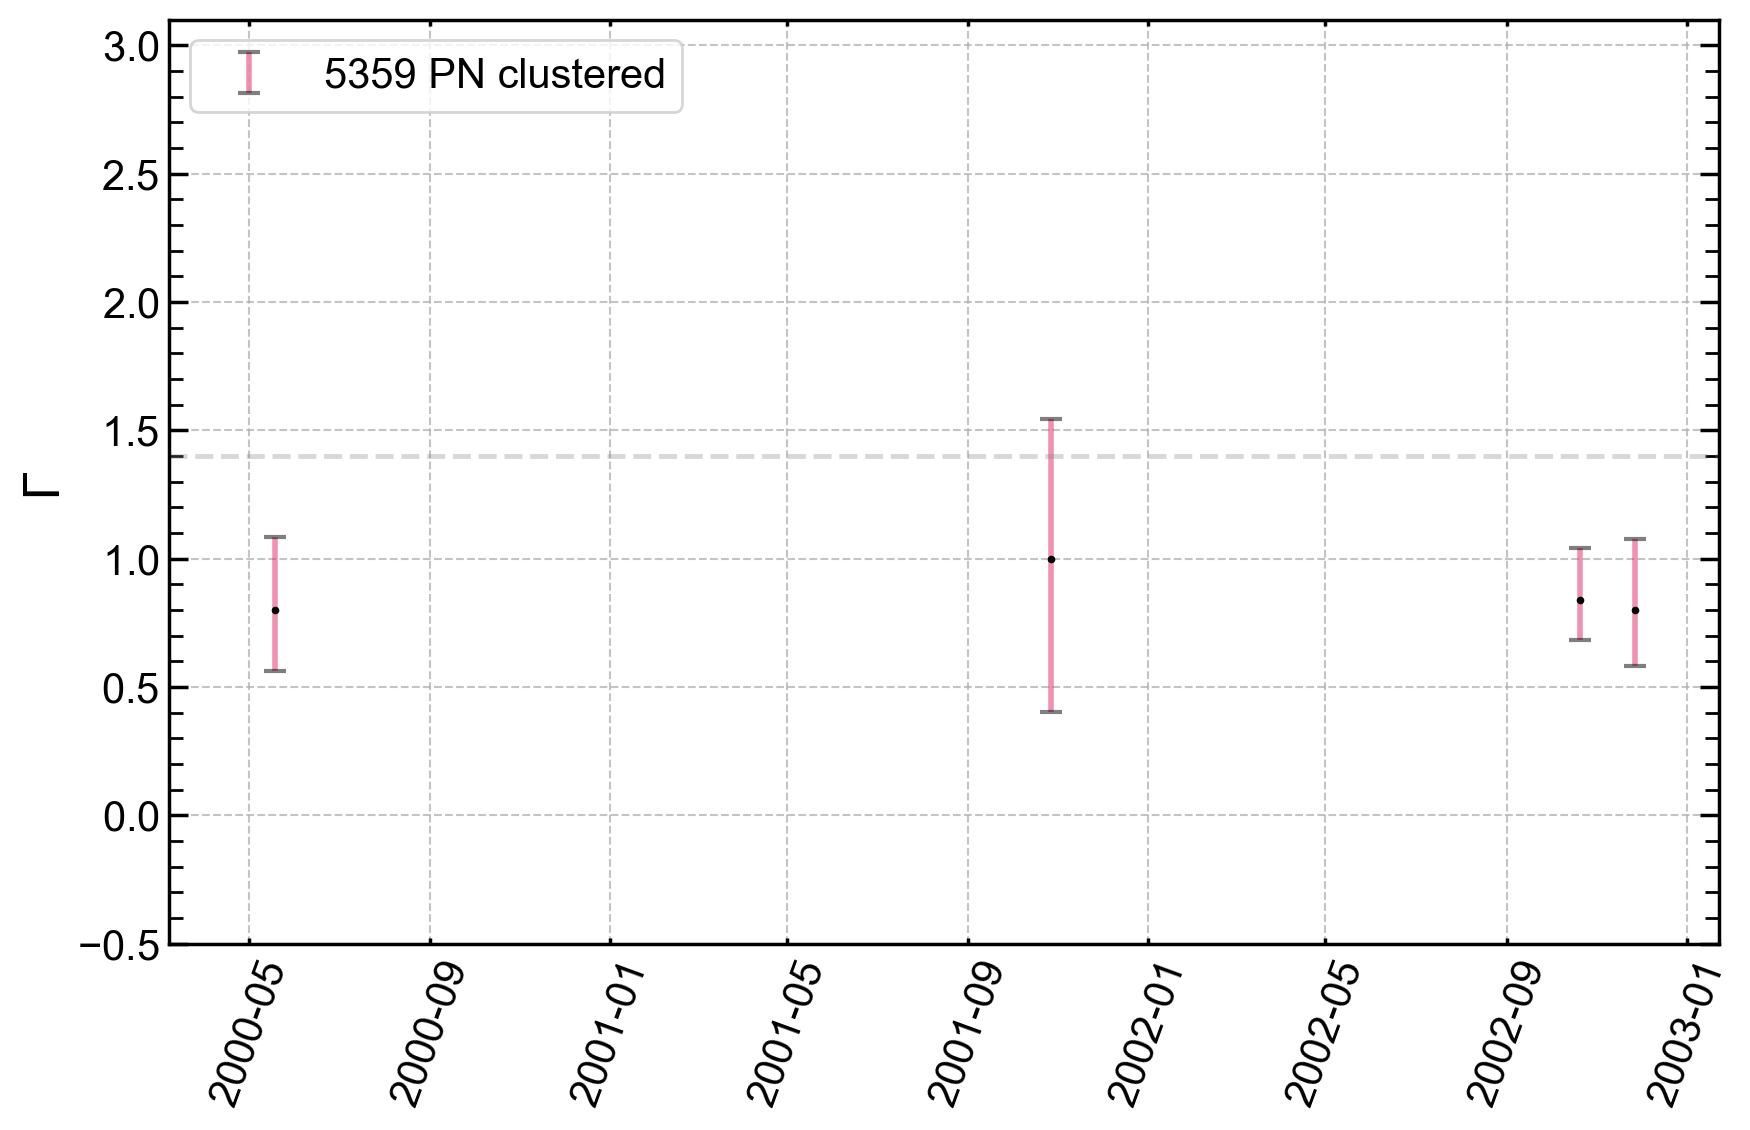

In [19]:
src_5359_df = pd.read_csv('../data/source_201237001010017_5359_clustered_PN_gap30_results.csv')

plot_date_gamma(src_5359_df, "5359 PN clustered", color='C1')

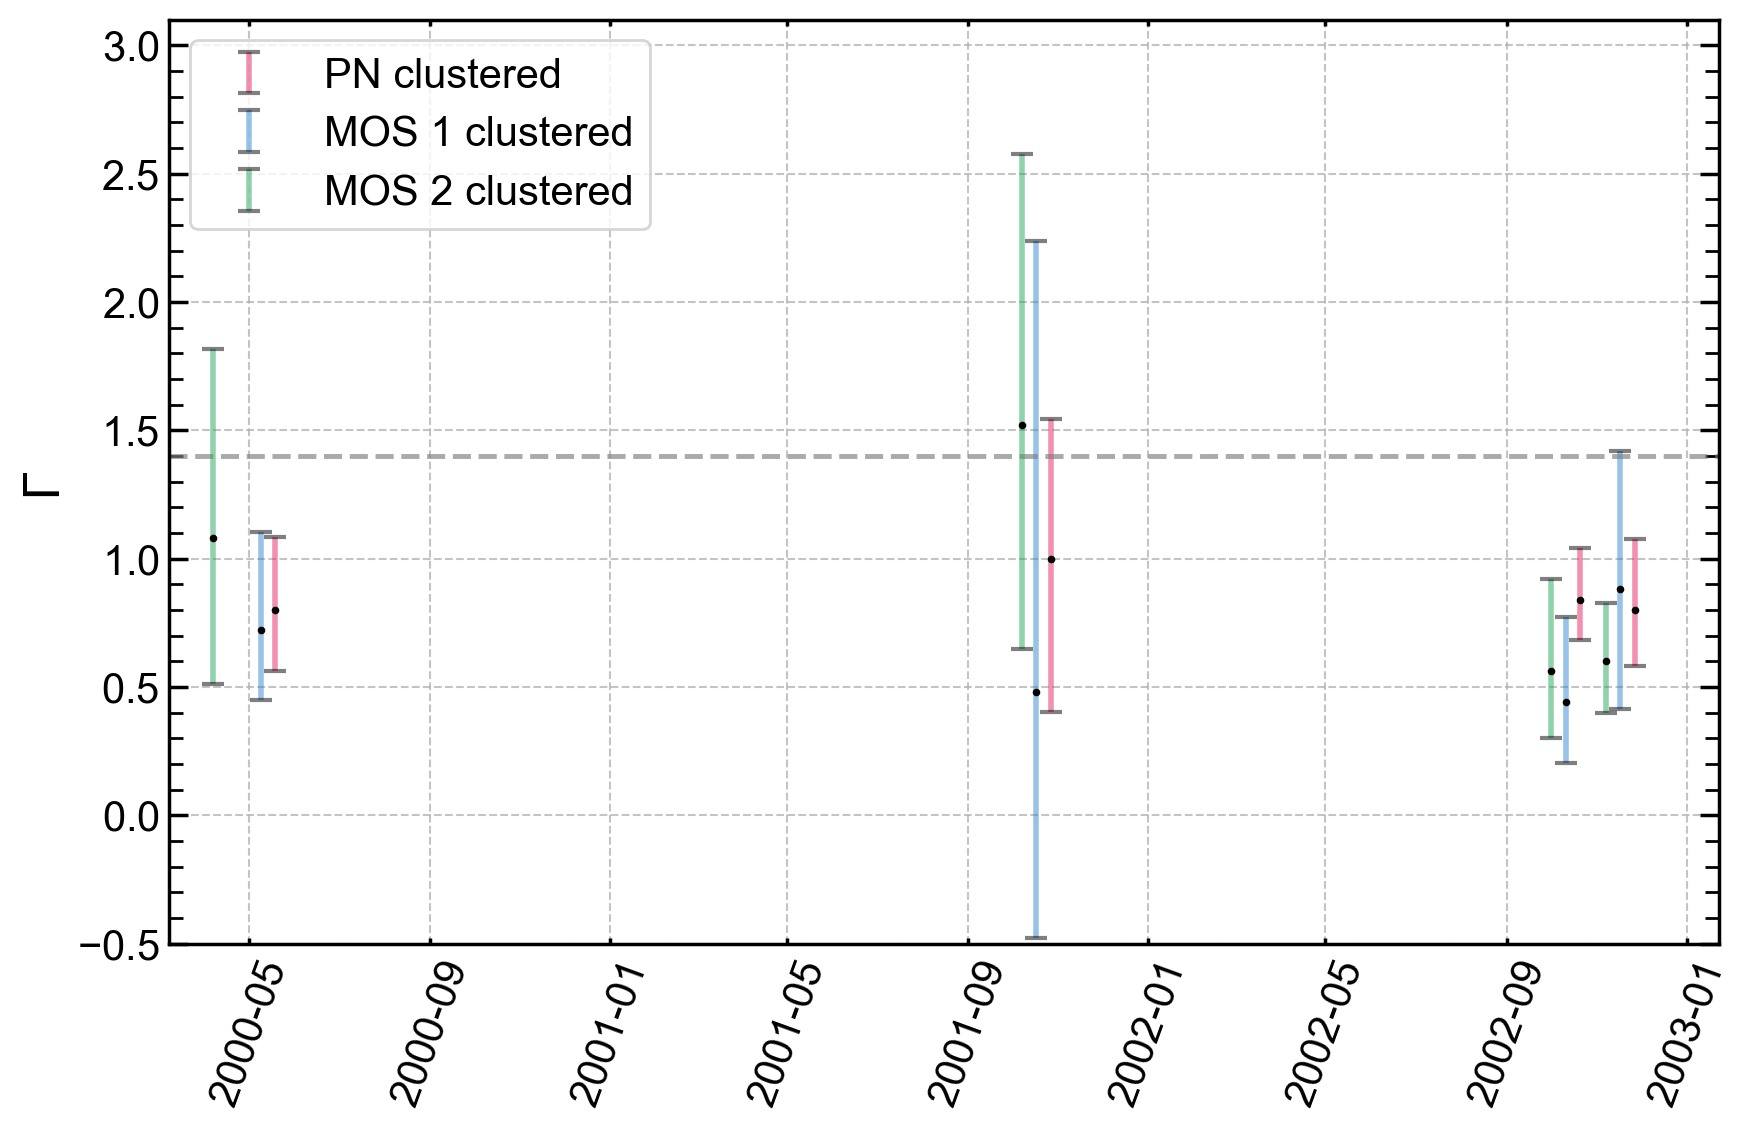

In [51]:
ax = plot_date_gamma(src_5359_df, "PN clustered", color='C1', pad_days=0)
plot_date_gamma(src_5359_M1_cluster_df, "MOS 1 clustered", color='C0', ax=ax, pad_days=-10)
plot_date_gamma(src_5359_M2_cluster_df, "MOS 2 clustered", color='C2', ax=ax, pad_days=-20)

plt.show()

In [20]:
# dfs = [src_1430_df, src_5359_df, src_7170_df]
# srcids = "1430", "5359", "7170"

# for df, title in zip(dfs, srcids):
#     plot_date_gamma(df, title)

***

**Downloading details**

In [21]:
# df = pd.read_csv('../data/spectra_to_download/deep_xmm_lh_full_ontime.csv')

# slim_ontime_df = df.query('user_srcid == 5359').sort_values('pn_ontime', ascending=False)[target_columns].reset_index(drop=True)

# download_log_df = pd.read_csv('../data/downloaded_spectra/download_meta.csv')

# slim_status_df = download_log_df[['src_num', 'obs_id', 'status']]

# slim_ontime_df.merge(slim_status_df, on=['src_num', 'obs_id'])

***

### 1430

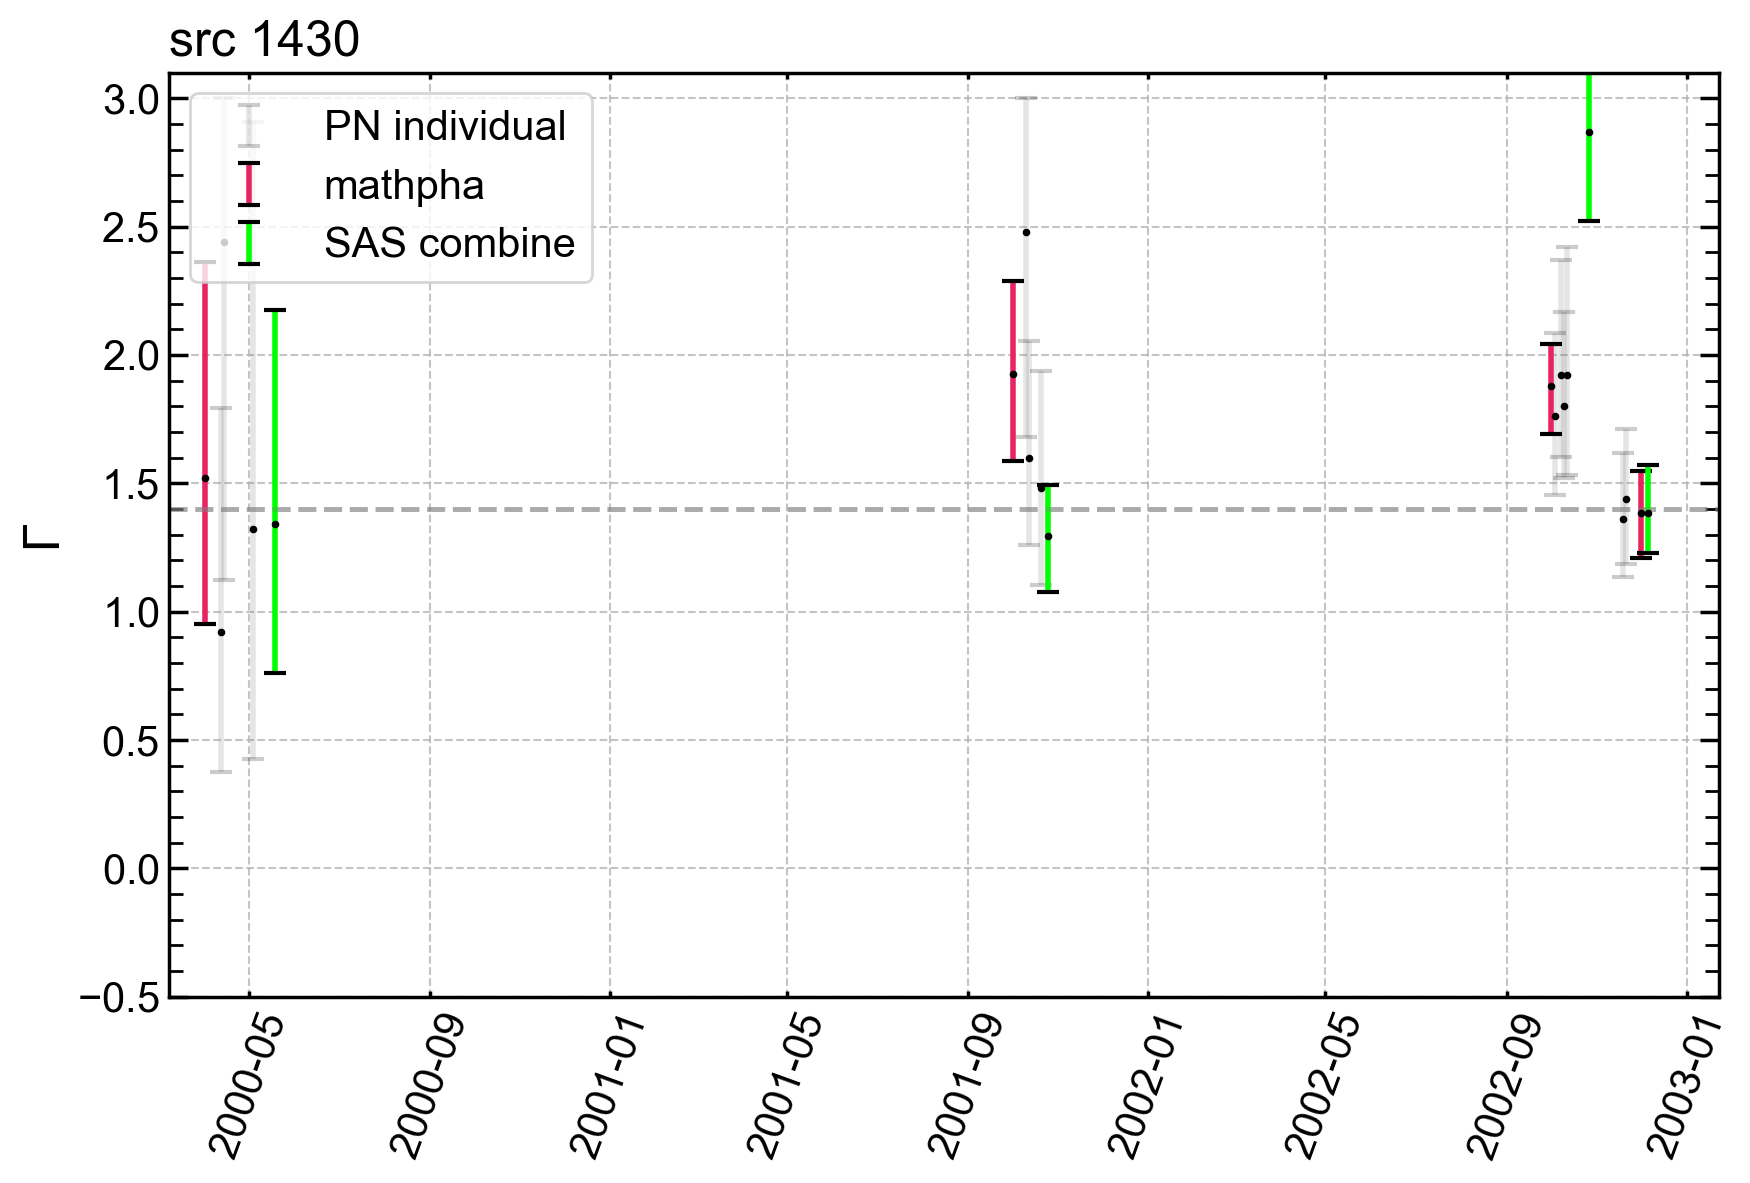

In [22]:
src_1430_PN_df = pd.read_csv('../data/source_201237001015028_1430_individual_PN_gap30_results.csv')
ax = plot_date_gamma(src_1430_PN_df, "PN individual", color='gray', alpha=0.2, pad=True)

src_1430_PN_addspec_df = pd.read_csv('../data/source_201237001015028_1430_clustered_PN_gap30_addspec_results.csv')
ax = plot_date_gamma(src_1430_PN_addspec_df, "mathpha", color='C1', alpha=1, ax=ax)

src_1430_PN_sascombine_df = pd.read_csv('../data/source_201237001015028_1430_clustered_PN_gap30_epicspeccombine_results.csv')
ax = plot_date_gamma(src_1430_PN_sascombine_df, "SAS combine", color='lime', alpha=1, ax=ax)

ax.set_title('src 1430', loc='left')
plt.show()

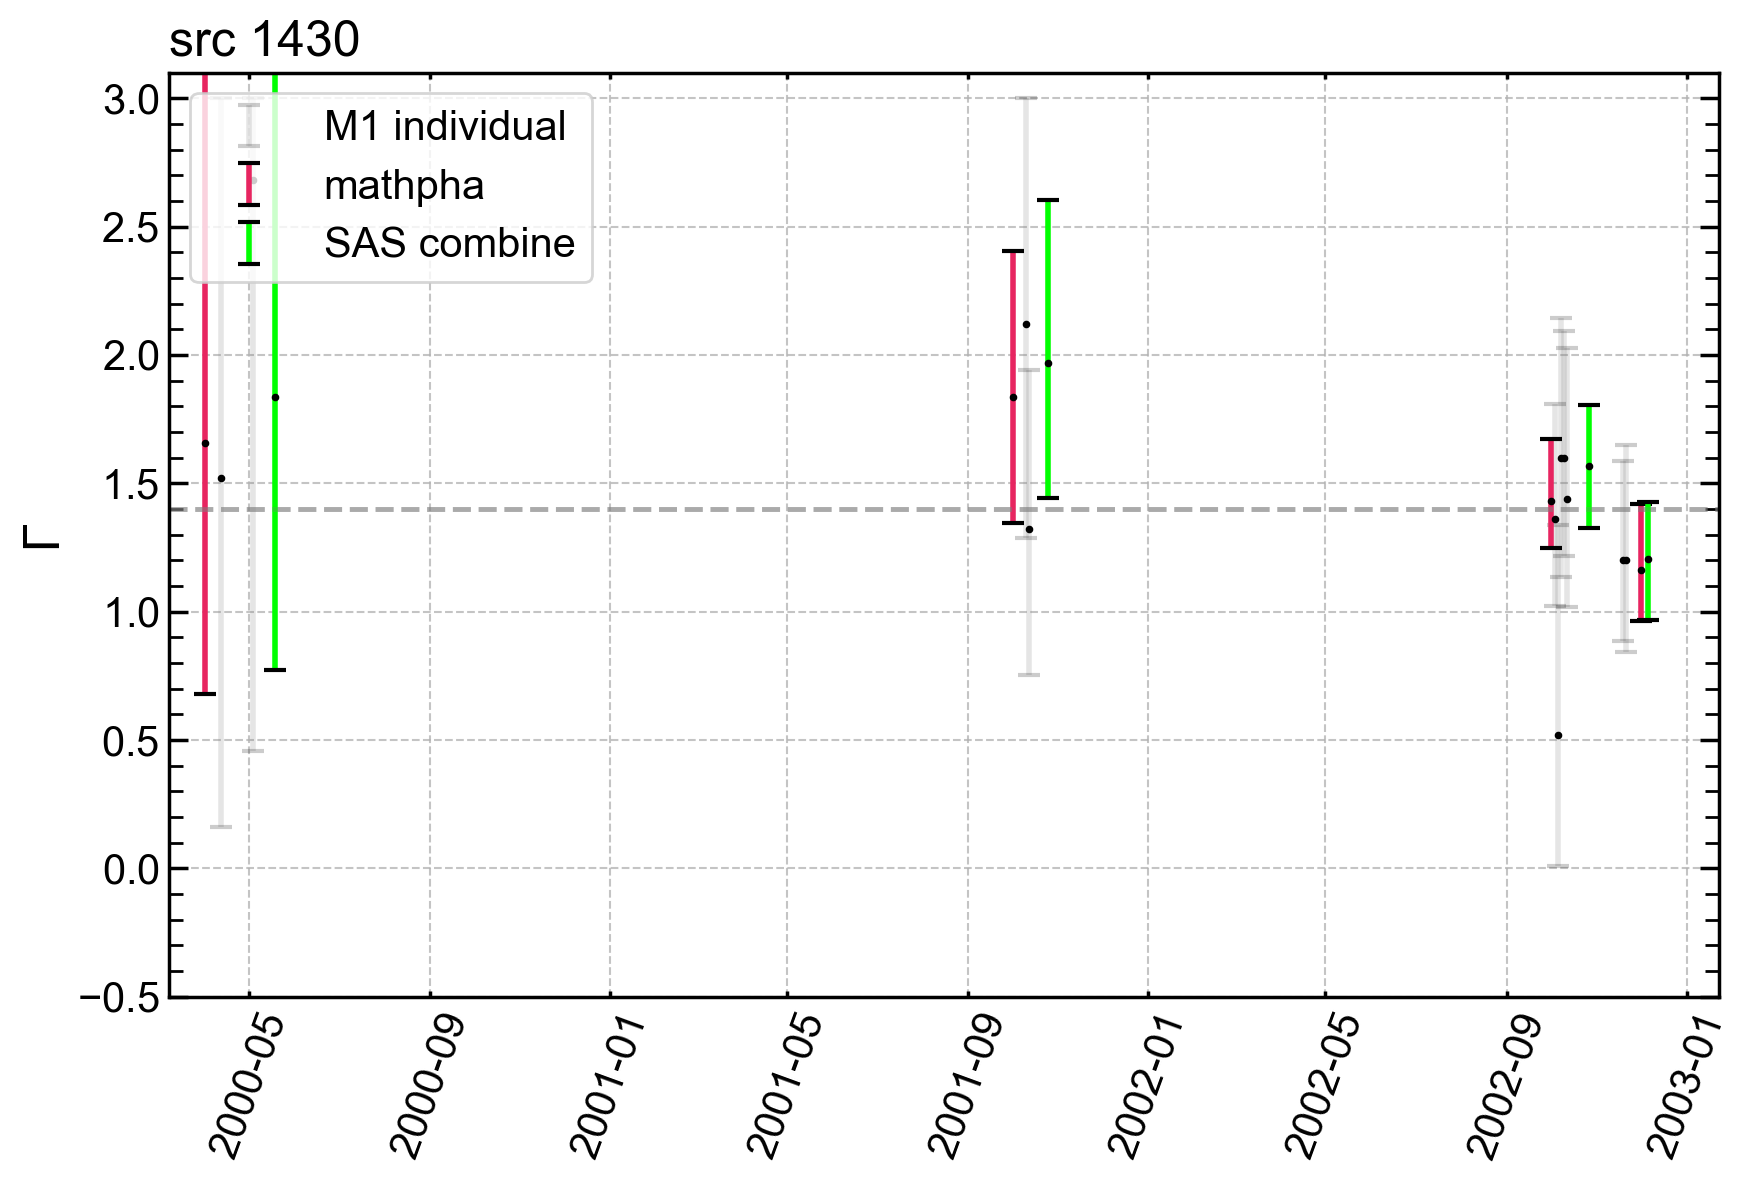

In [23]:
src_1430_M1_df = pd.read_csv('../data/source_201237001015028_1430_individual_M1_gap30_results.csv')
ax = plot_date_gamma(src_1430_M1_df, "M1 individual", color='gray', alpha=0.2, pad=True)

src_1430_M1_addspec_df = pd.read_csv('../data/source_201237001015028_1430_clustered_M1_gap30_addspec_results.csv')
ax = plot_date_gamma(src_1430_M1_addspec_df, "mathpha", color='C1', alpha=1, ax=ax)

src_1430_M1_sascombine_df = pd.read_csv('../data/source_201237001015028_1430_clustered_M1_gap30_epicspeccombine_results.csv')
ax = plot_date_gamma(src_1430_M1_sascombine_df, "SAS combine", color='lime', alpha=1, ax=ax)

ax.set_title('src 1430', loc='left')
plt.show()

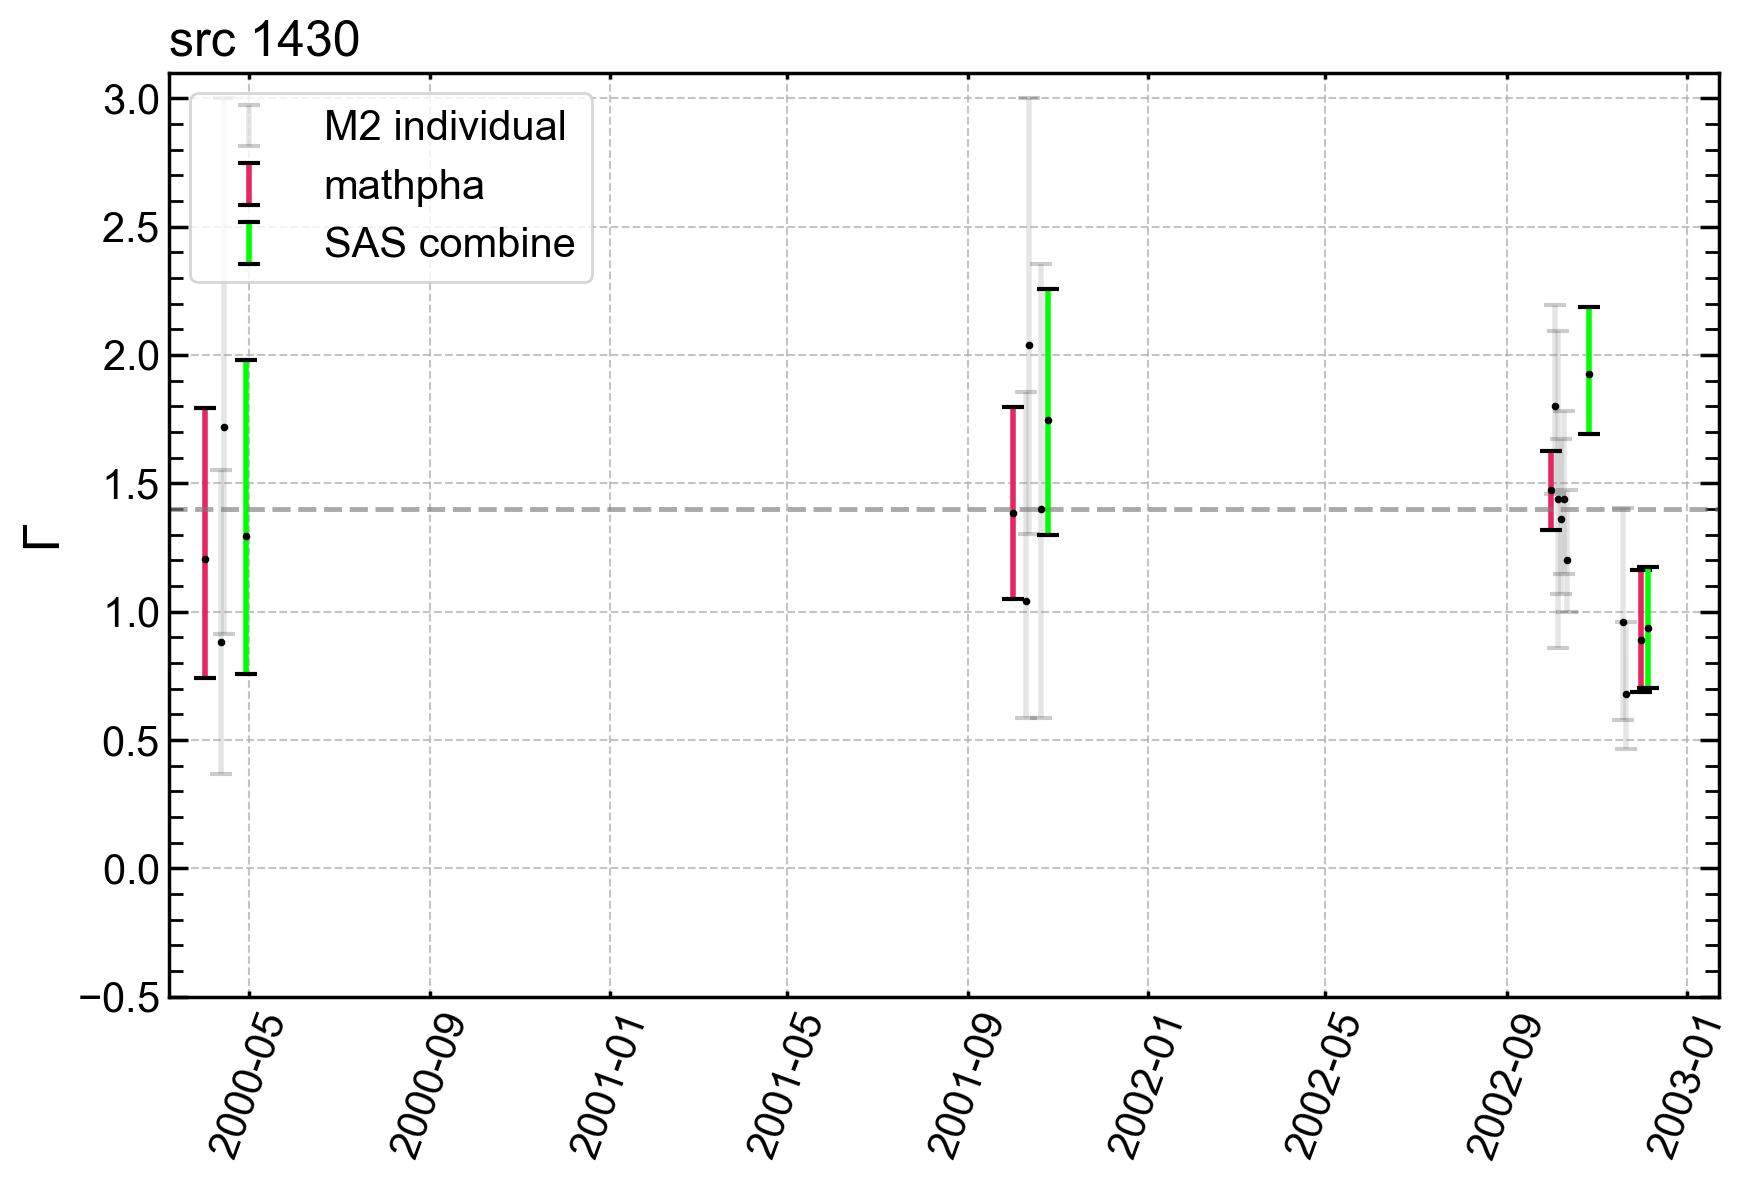

In [24]:
src_1430_M2_df = pd.read_csv('../data/source_201237001015028_1430_individual_M2_gap30_results.csv')
ax = plot_date_gamma(src_1430_M2_df, "M2 individual", color='gray', alpha=0.2, pad=True)

src_1430_M2_addspec_df = pd.read_csv('../data/source_201237001015028_1430_clustered_M2_gap30_addspec_results.csv')
ax = plot_date_gamma(src_1430_M2_addspec_df, "mathpha", color='C1', alpha=1, ax=ax)

src_1430_M2_sascombine_df = pd.read_csv('../data/source_201237001015028_1430_clustered_M2_gap30_epicspeccombine_results.csv')
ax = plot_date_gamma(src_1430_M2_sascombine_df, "SAS combine", color='lime', alpha=1, ax=ax)

ax.set_title('src 1430', loc='left')
plt.show()

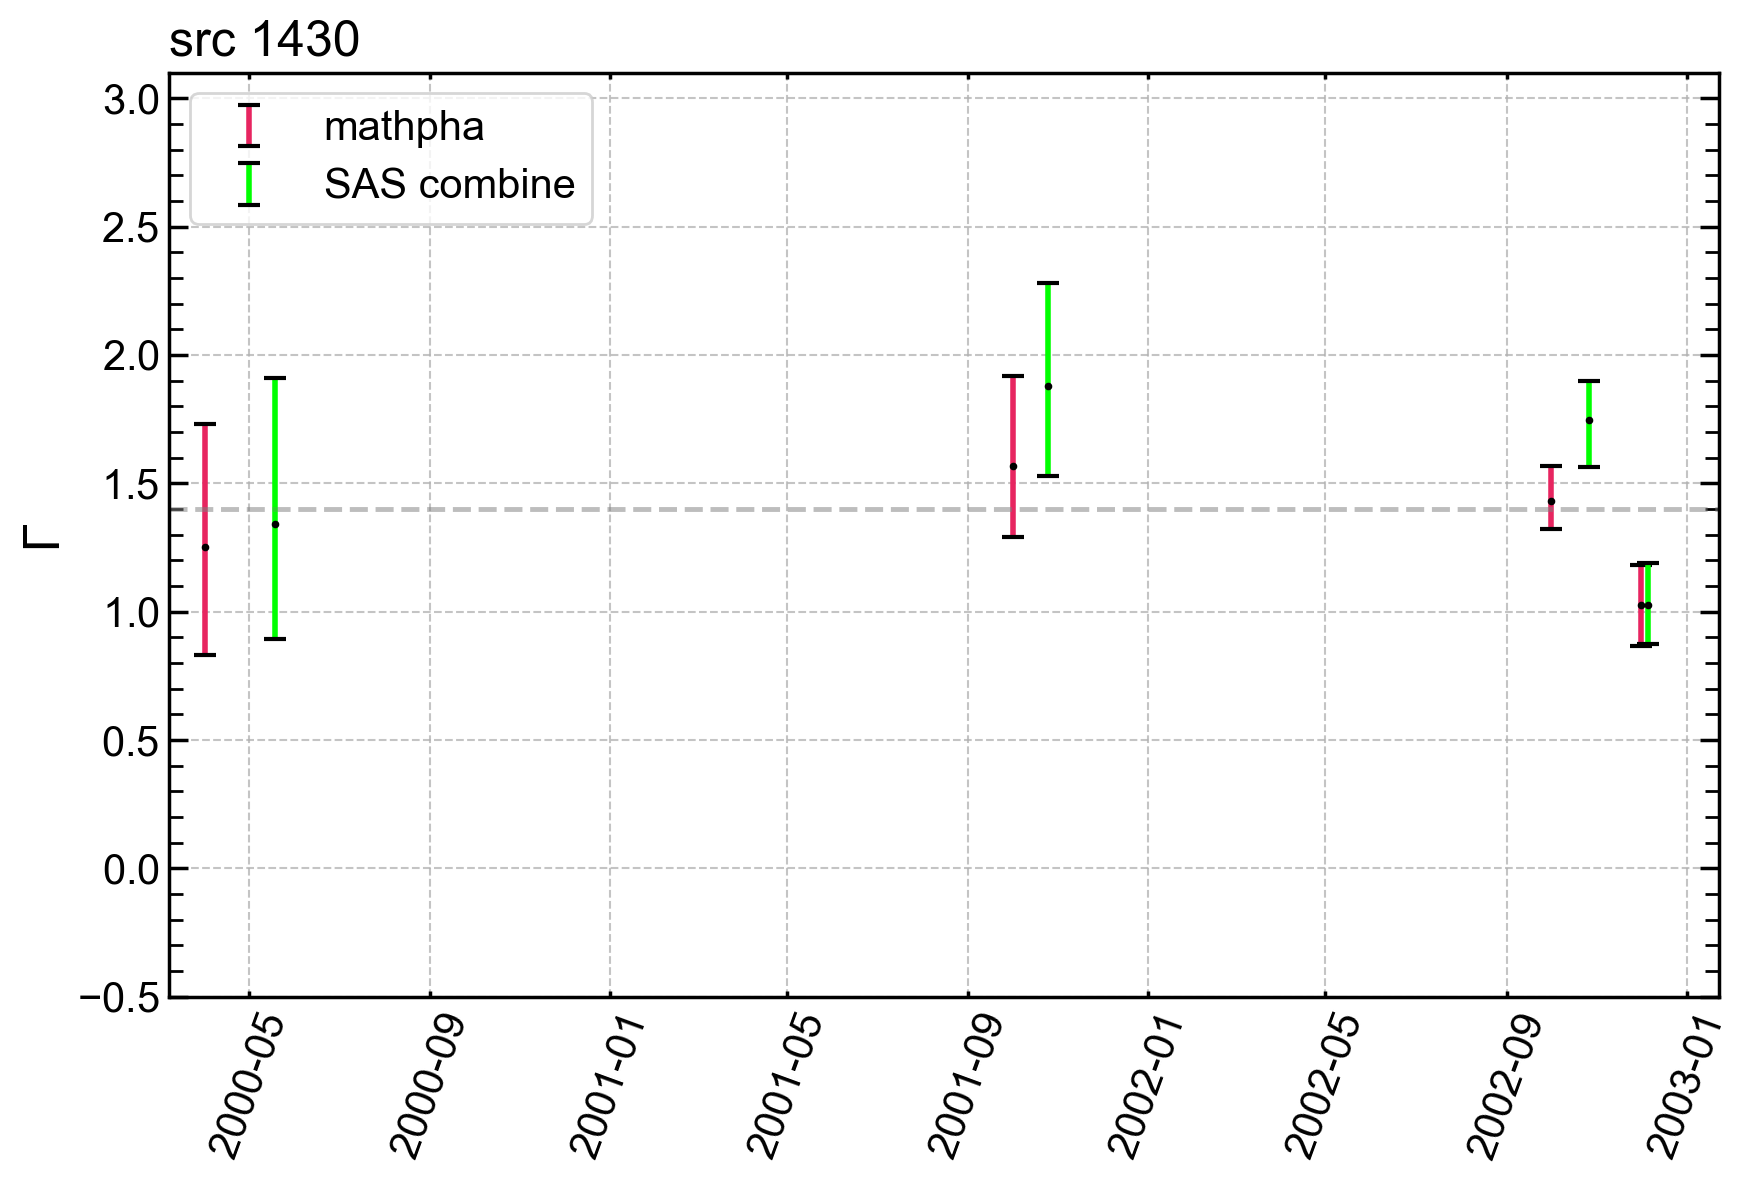

In [25]:
# src_1430_MOS_df = pd.read_csv('../data/source_201237001015028_1430_individual_MOS_gap30_results.csv')
# ax = plot_date_gamma(src_1430_MOS_df, "1430 MOS", color='gray', alpha=0.2, pad=True)

src_1430_MOS_addspec_df = pd.read_csv('../data/source_201237001015028_1430_clustered_MOS_gap30_addspec_results.csv')
ax = plot_date_gamma(src_1430_MOS_addspec_df, "mathpha", color='C1', alpha=1)

src_1430_MOS_sascombine_df = pd.read_csv('../data/source_201237001015028_1430_clustered_MOS_gap30_epicspeccombine_results.csv')
ax = plot_date_gamma(src_1430_MOS_sascombine_df, "SAS combine", color='lime', alpha=1, ax=ax)

ax.set_title('src 1430', loc='left')
plt.show()

In [26]:
src_1430_pn_df = pd.read_csv('../data/source_201237001015028_1430_individual_PN_gap30_results.csv')
src_1430_m1_df = pd.read_csv('../data/source_201237001015028_1430_individual_M1_gap30_results.csv')
src_1430_m2_df = pd.read_csv('../data/source_201237001015028_1430_individual_M2_gap30_results.csv')

<Axes: ylabel='Г'>

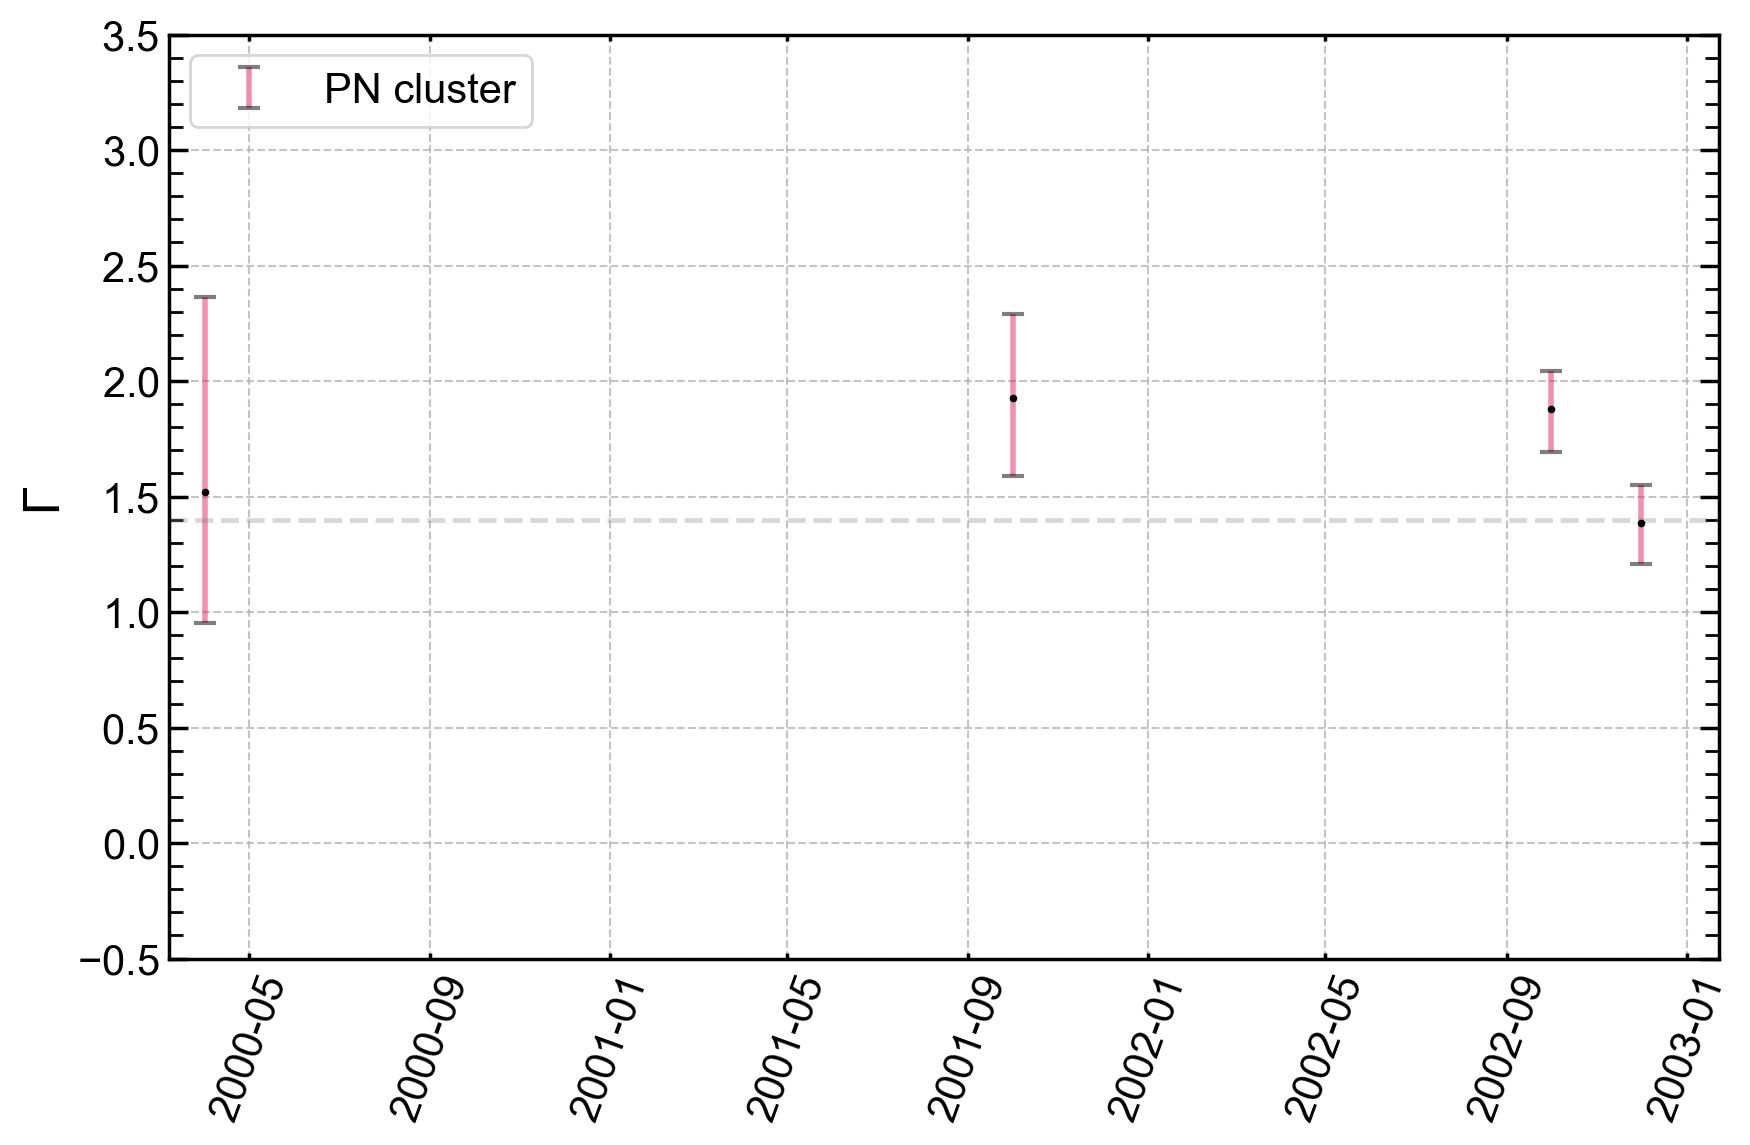

In [27]:
src_1430_pn_clustered_df = pd.read_csv(
    '../data/source_201237001015028_1430_clustered_PN_gap30_addspec_results.csv'
)

plot_date_gamma(src_1430_pn_clustered_df, 'PN cluster', 'C1', uplim=3.5)

<Axes: ylabel='Г'>

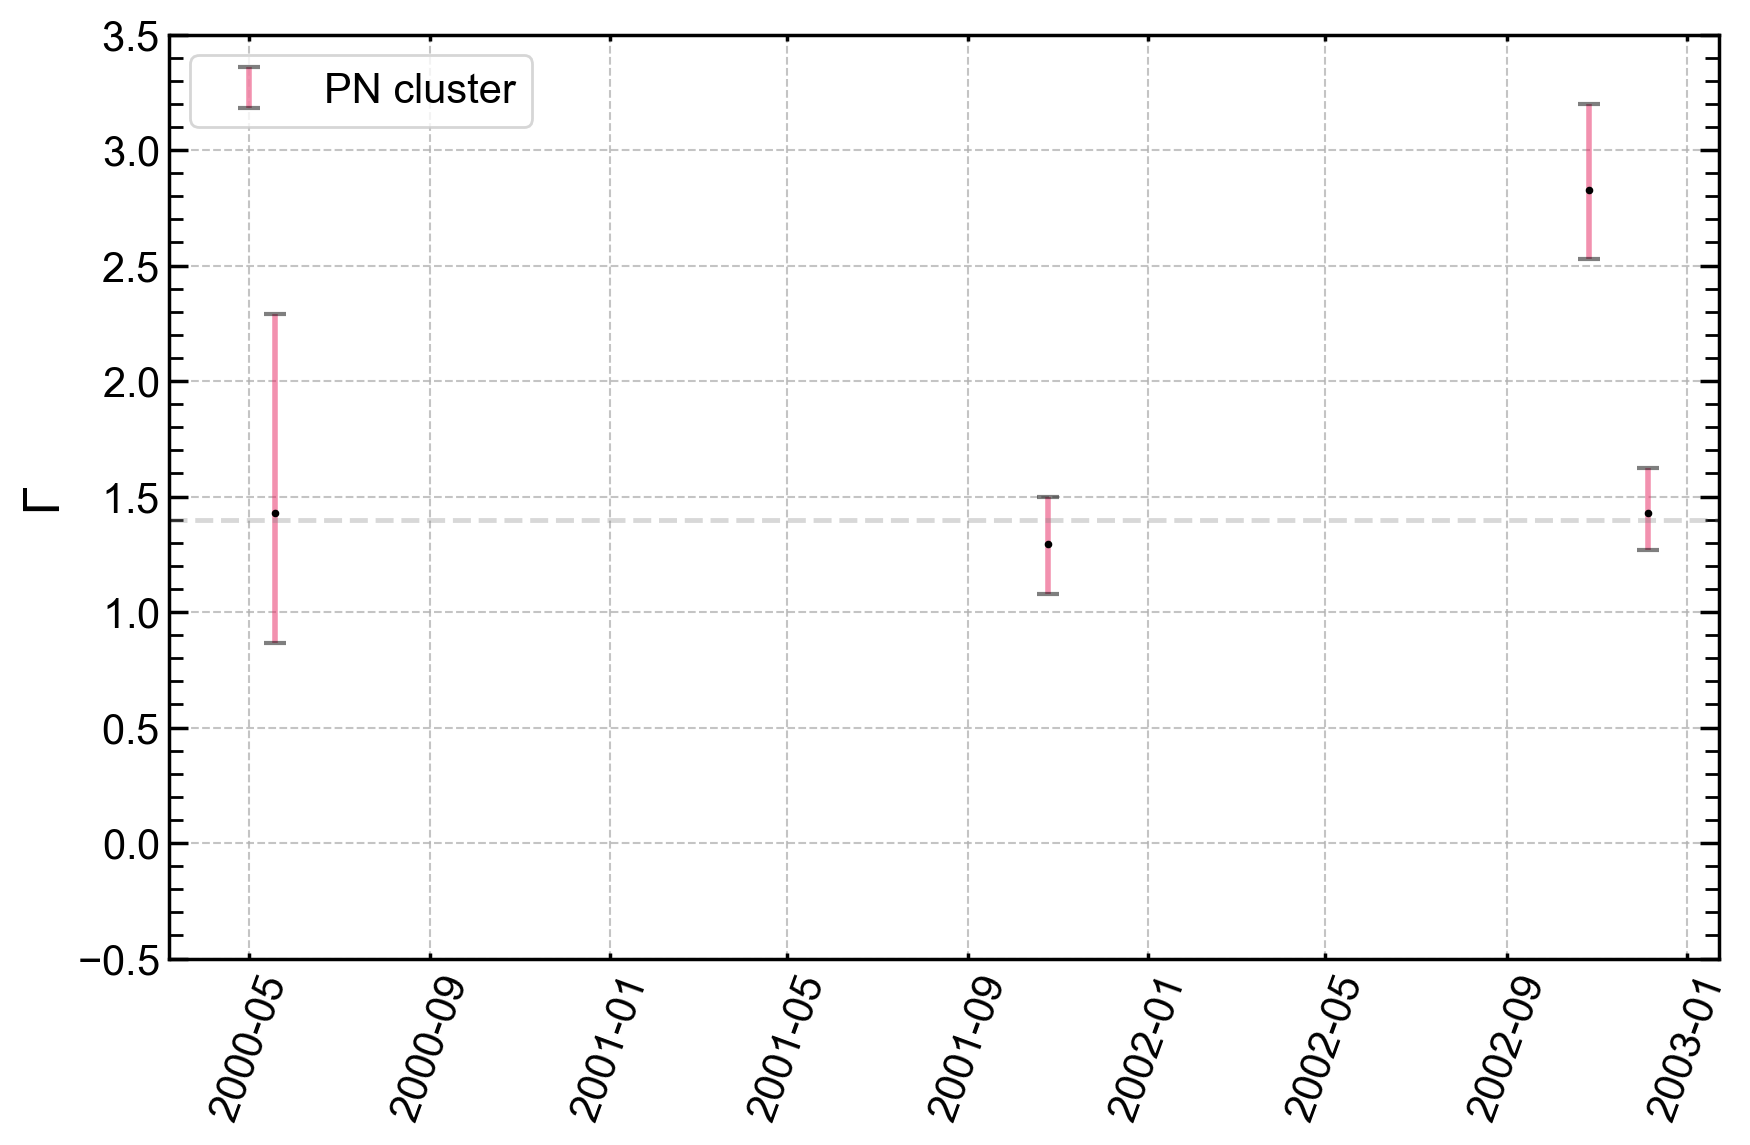

In [28]:
src_1430_pn_clustered_df = pd.read_csv(
    '../data/source_201237001015028_1430_clustered_PN_gap30_wide_step_results.csv'
)

plot_date_gamma(src_1430_pn_clustered_df, 'PN cluster', 'C1', uplim=3.5)

<Axes: ylabel='Г'>

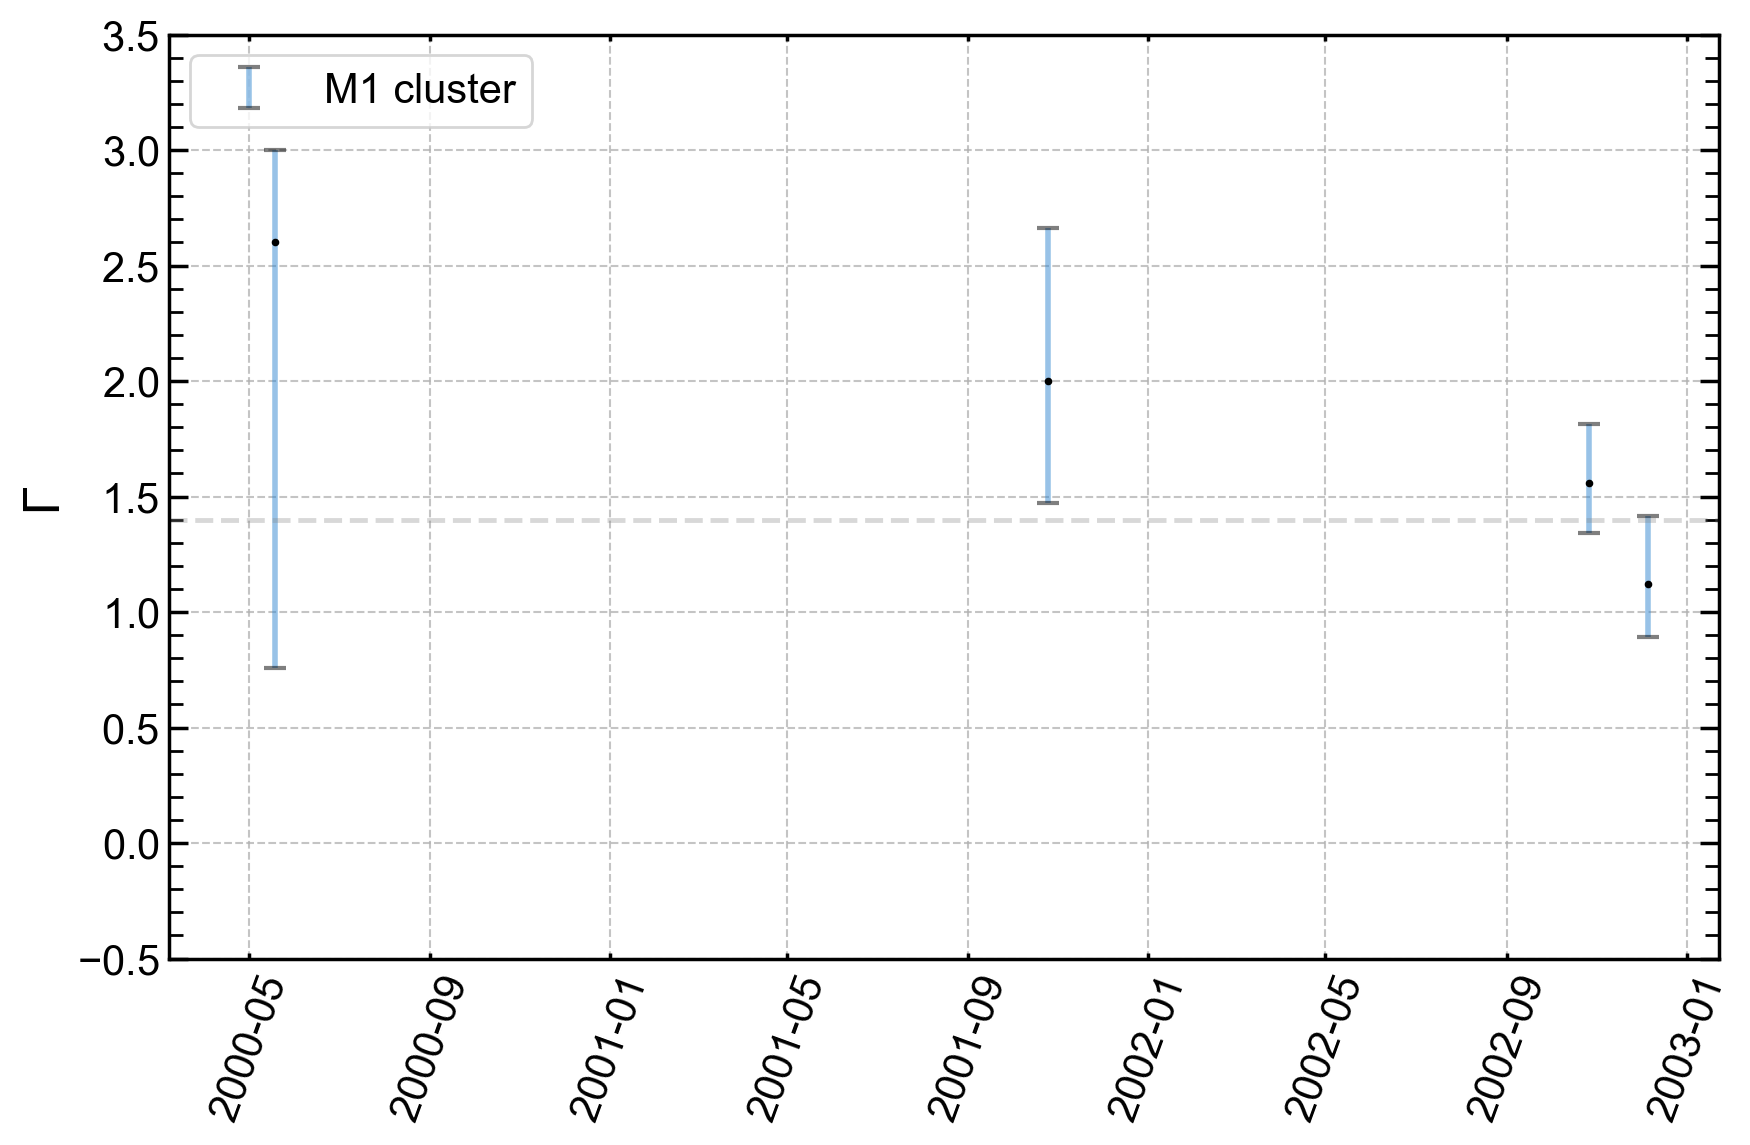

In [29]:
src_1430_M1_clustered_df = pd.read_csv(
    '../data/source_201237001015028_1430_clustered_M1_gap30_results.csv'
)

plot_date_gamma(src_1430_M1_clustered_df, 'M1 cluster', 'C0', uplim=3.5)

<Axes: ylabel='Г'>

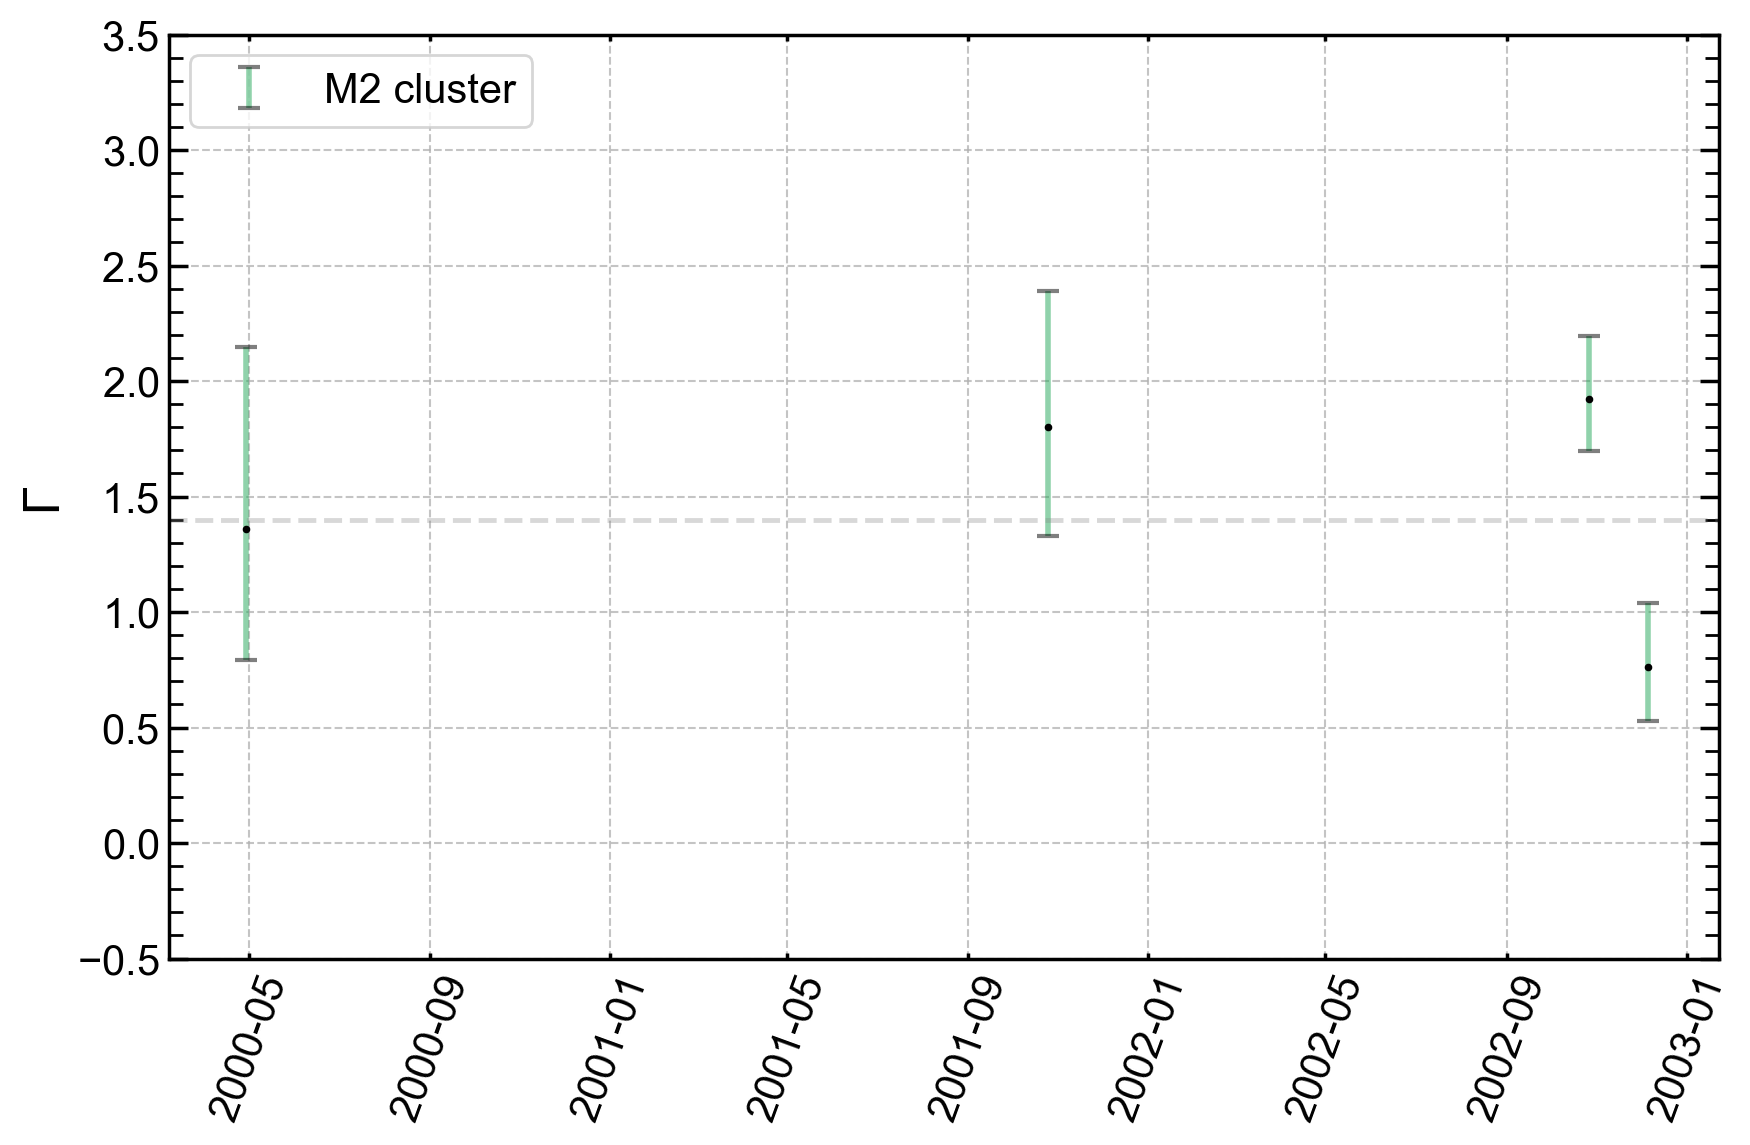

In [30]:
src_1430_M2_clustered_df = pd.read_csv(
    '../data/source_201237001015028_1430_clustered_M2_gap30_results.csv'
)

plot_date_gamma(src_1430_M2_clustered_df, 'M2 cluster', 'C2', uplim=3.5)

<Axes: ylabel='Г'>

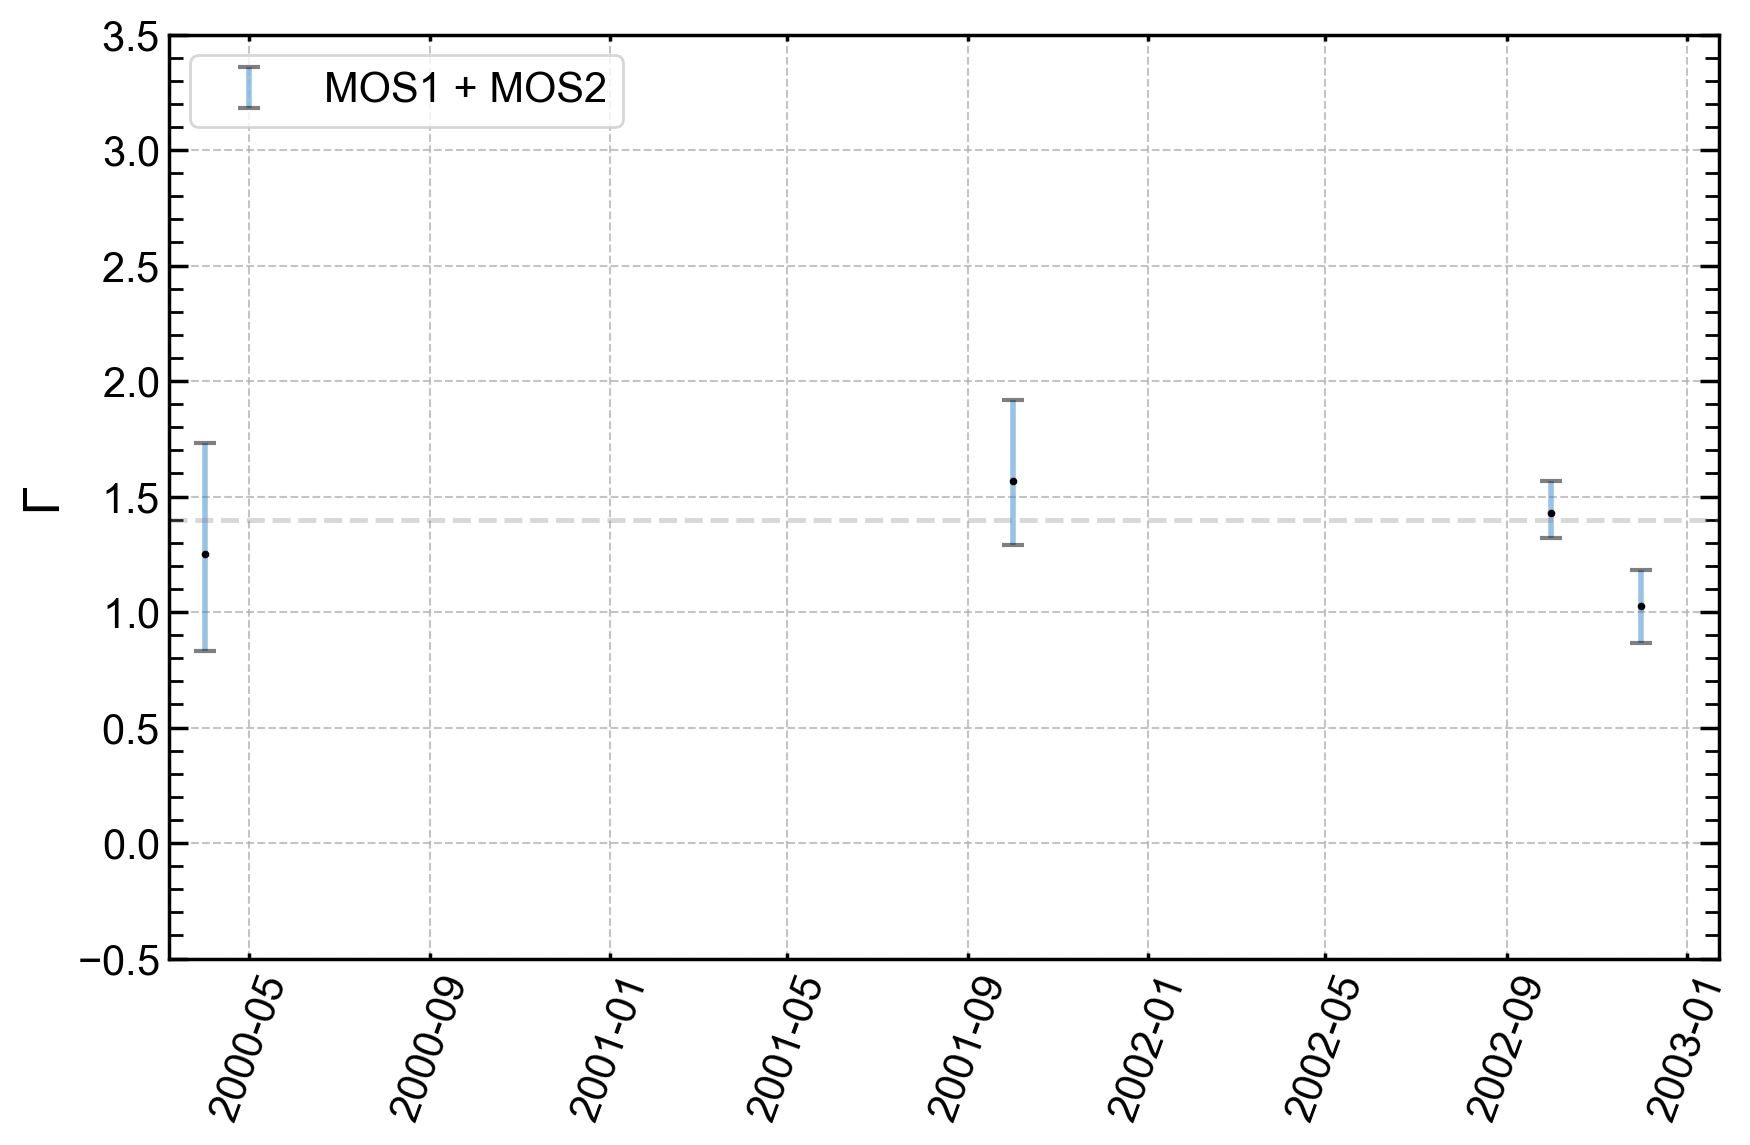

In [31]:
src_1430_MOS_clustered_df = pd.read_csv(
    '../data/source_201237001015028_1430_clustered_MOS_gap30_addspec_results.csv'
)

plot_date_gamma(src_1430_MOS_clustered_df, 'MOS1 + MOS2', 'C0', uplim=3.5)

<Axes: ylabel='Г'>

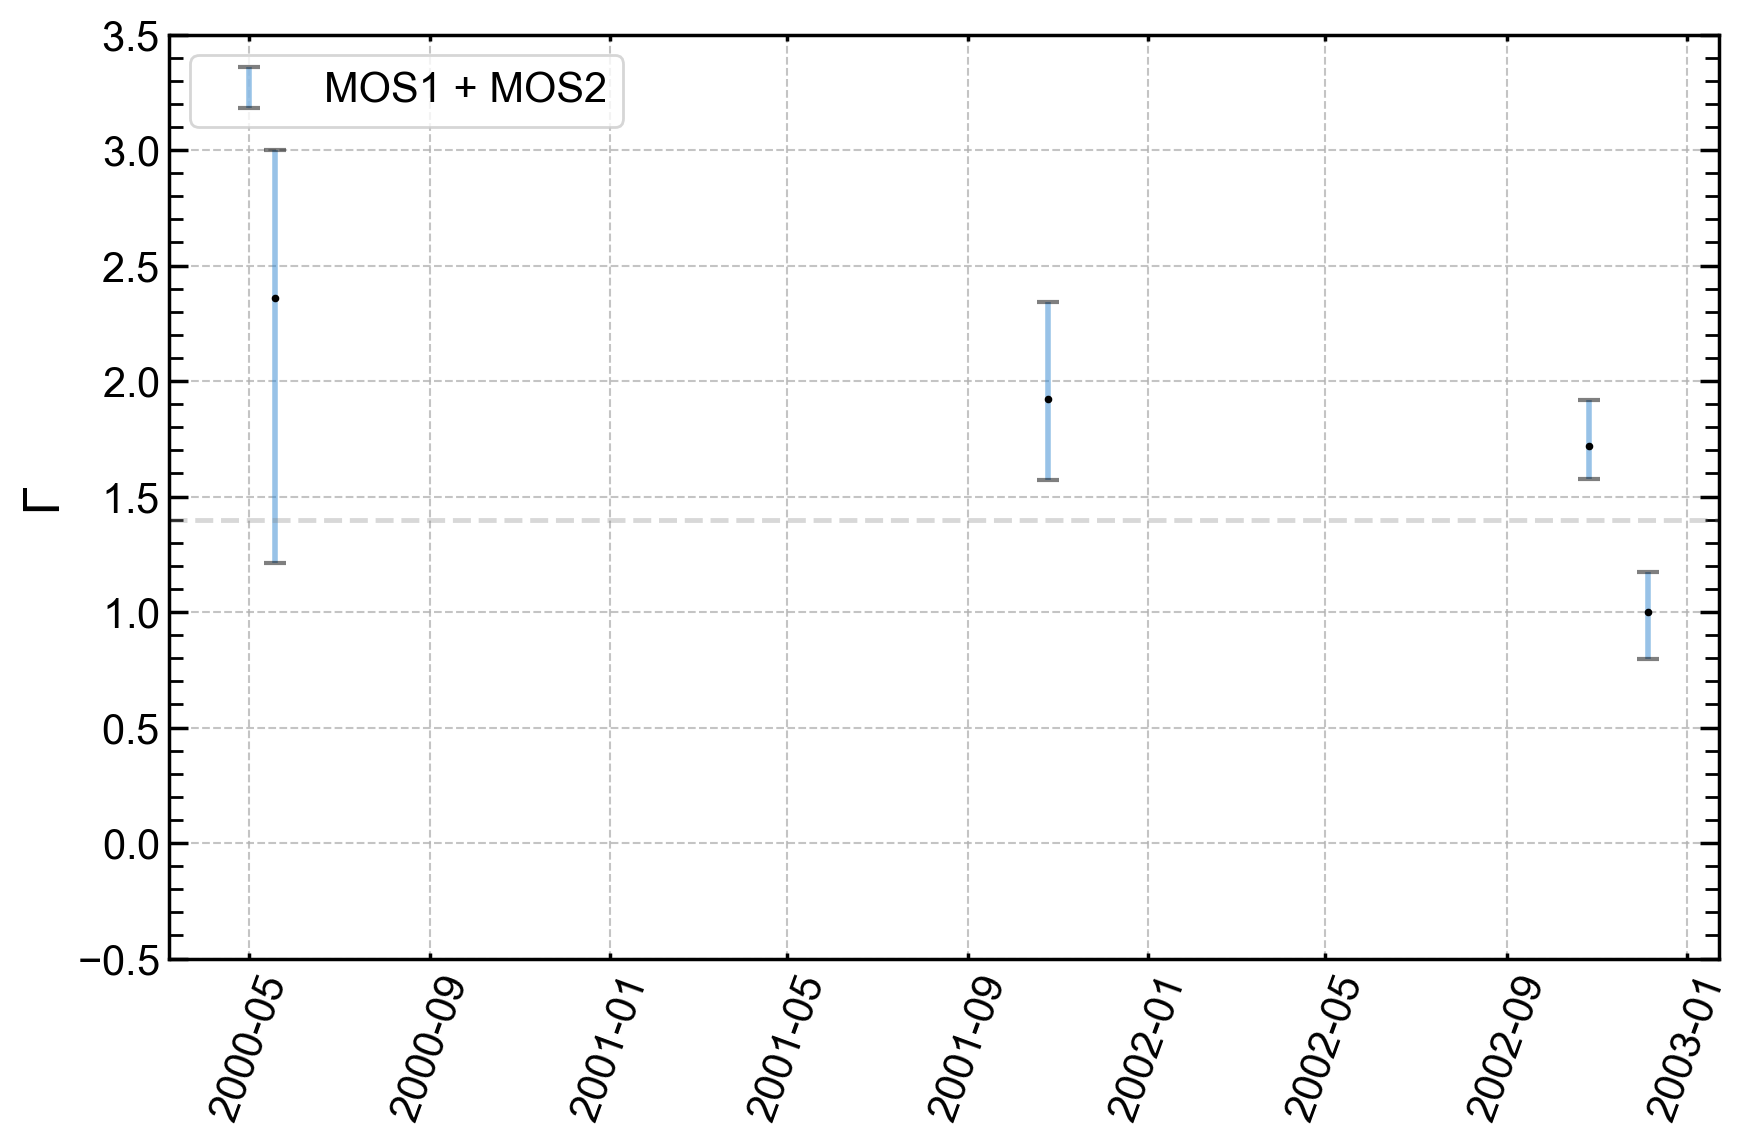

In [32]:
src_1430_MOS_clustered_df = pd.read_csv(
    '../data/source_201237001015028_1430_clustered_MOS_gap30_results.csv'
)

plot_date_gamma(src_1430_MOS_clustered_df, 'MOS1 + MOS2', 'C0', uplim=3.5)

In [33]:
pn_dates_df = pd.read_pickle('/Users/mike/Yandex.Disk.localized/Работа/ИКИ/Y.repos/lh_obscurus/data/xmm_spectra/srcid_1430/mo2_fit_individual_only_2d_steppar_PN_flux_etc_eRASS_2.pkl')
pn_df = pd.read_pickle('/Users/mike/Yandex.Disk.localized/Работа/ИКИ/Y.repos/lh_obscurus/data/xmm_spectra/srcid_1430/1430_mo2_fit_2d_steppar_hd.pkl')

pn_df.columns = [
    'mo2_nH_step_2d', 'mo2_nH_step_2d_perr', 'mo2_nH_step_2d_nerr',
    'mo2_PhoIndex_step_2d', 'mo2_PhoIndex_step_2d_perr', 'mo2_PhoIndex_step_2d_nerr',
    ]

pn_df['date_obs'] = pn_dates_df[1:]['date_obs'].values
pn_df['flux'] = pn_dates_df[1:]['flux'].values
pn_df['flux_nerr'] = pn_dates_df[1:]['flux_nerr'].values
pn_df['flux_perr'] = pn_dates_df[1:]['flux_perr'].values

pn_df

,mo2_nH_step_2d,mo2_nH_step_2d_perr,mo2_nH_step_2d_nerr,mo2_PhoIndex_step_2d,mo2_PhoIndex_step_2d_perr,mo2_PhoIndex_step_2d_nerr,date_obs,flux,flux_nerr,flux_perr
0,1.135237,0.961319,0.617911,1.385714,0.483021,0.390077,2000-04-27 03:34:45,5.873586e-15,4.034901e-15,6.313091e-15
0,1.191759,0.436537,0.352293,1.614286,0.219312,0.209117,2001-10-27 19:10:18,1.250138e-14,1.148761e-14,1.311962e-14
0,0.497001,0.126184,0.126085,1.214286,0.092534,0.085680,2002-11-27 23:26:55,1.184899e-14,1.137758e-14,1.219247e-14


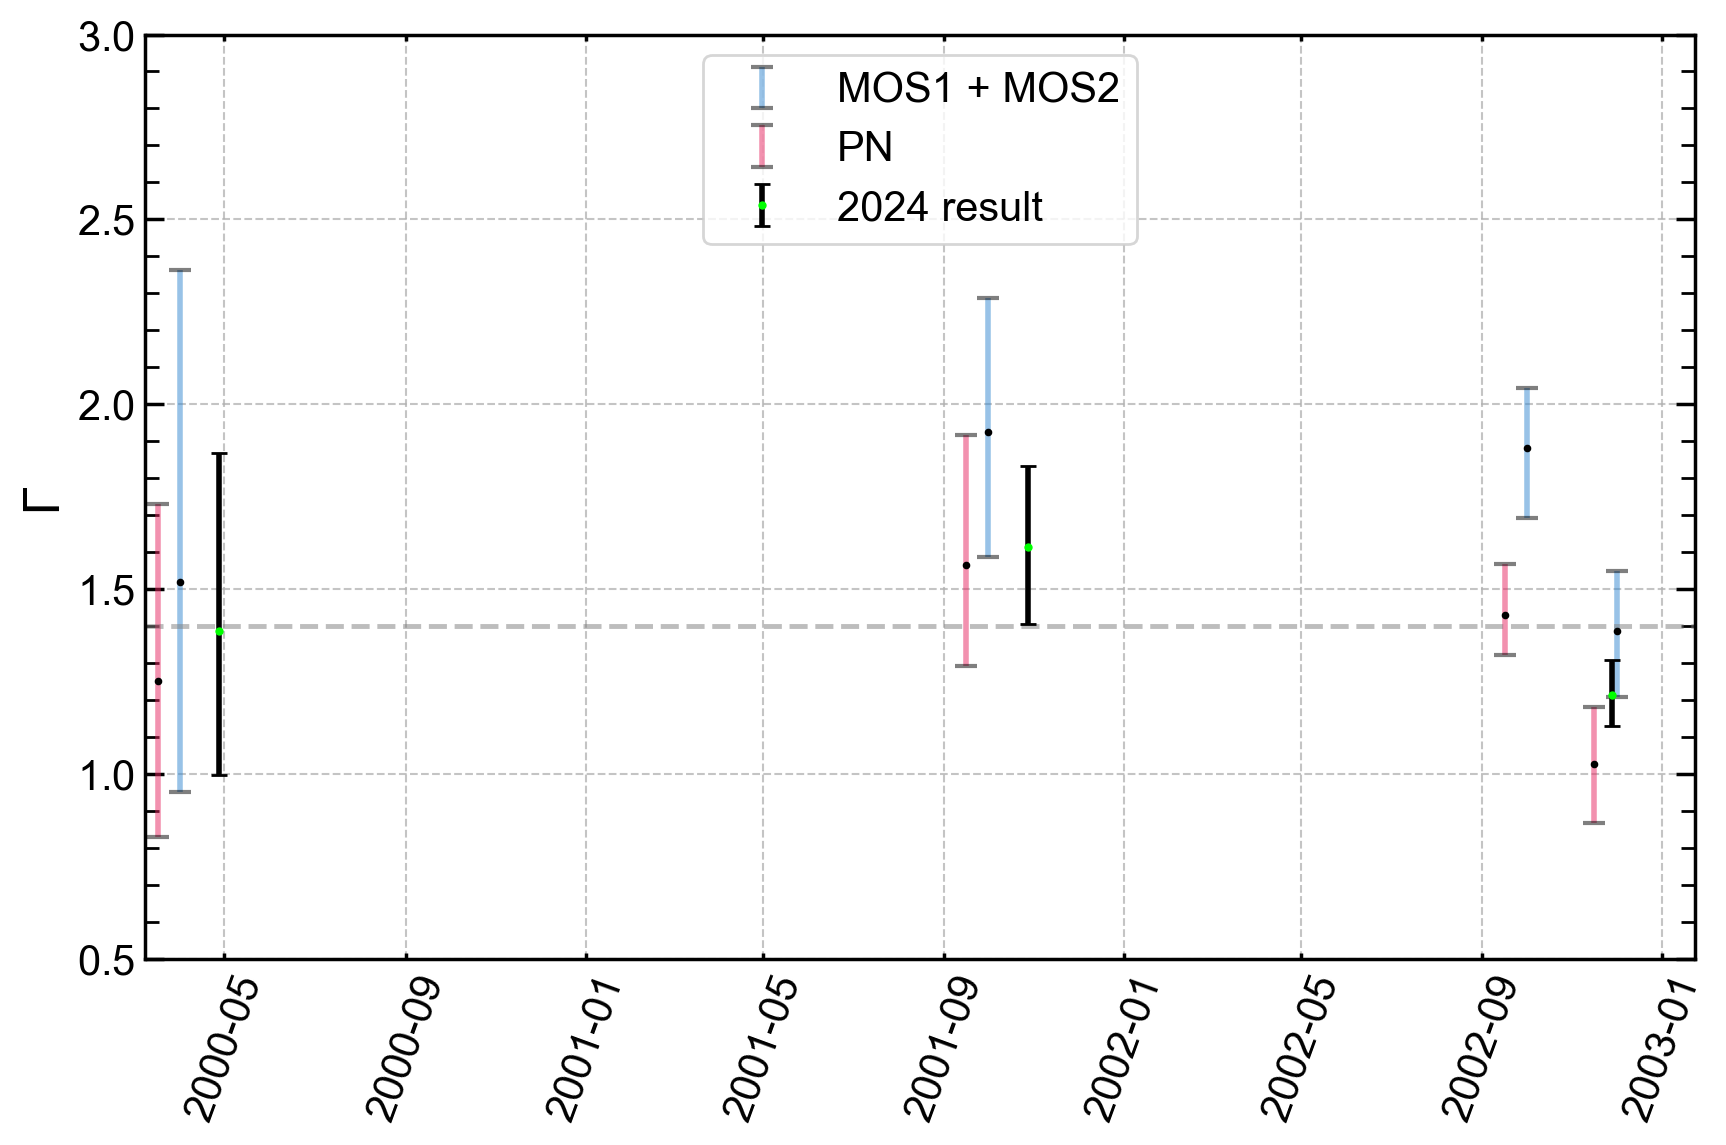

In [34]:
src_1430_MOS_df = pd.read_csv('../data/source_201237001015028_1430_clustered_PN_gap30_addspec_results.csv')
ax = plot_date_gamma(src_1430_MOS_df, 'MOS1 + MOS2', color='C0', uplim=3)

src_1430_PN_df = pd.read_csv('../data/source_201237001015028_1430_clustered_MOS_gap30_addspec_results.csv')
ax = plot_date_gamma(
    src_1430_PN_df, "PN", color='C1', ax=ax, pad=True, lolim=0.5, uplim=3
    )

ax.errorbar(
    x=pn_df['date_obs'], y=pn_df['mo2_PhoIndex_step_2d'],
    yerr=[pn_df['mo2_PhoIndex_step_2d_nerr'], pn_df['mo2_PhoIndex_step_2d_perr']],
    fmt='o', markersize=3, color='lime', capsize=3, capthick=1, ecolor='k', lw=2,
    label='2024 result'
    )

ax.legend(loc='upper center')

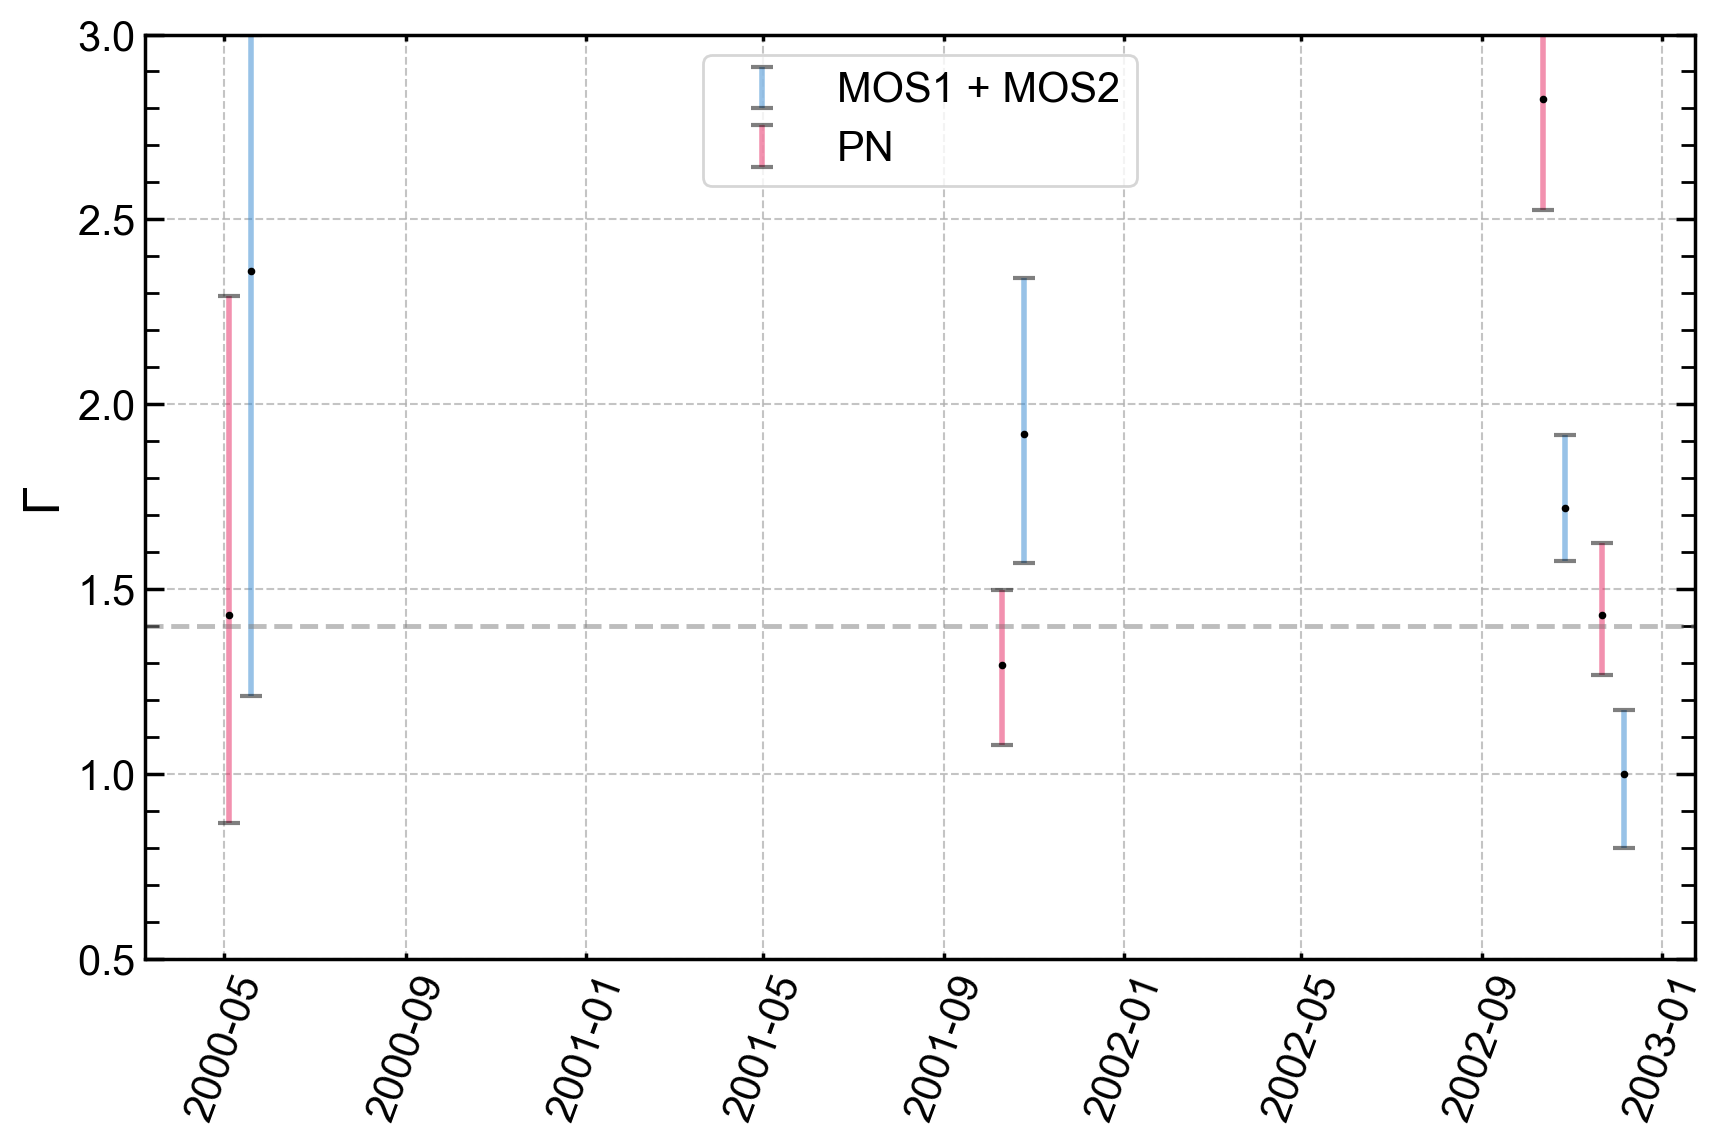

In [35]:
src_1430_MOS_df = pd.read_csv('../data/source_201237001015028_1430_clustered_MOS_gap30_results.csv')
ax = plot_date_gamma(src_1430_MOS_df, 'MOS1 + MOS2', color='C0', uplim=3)

src_1430_PN_df = pd.read_csv('../data/source_201237001015028_1430_clustered_PN_gap30_wide_step_results.csv')
ax = plot_date_gamma(
    src_1430_PN_df, "PN", color='C1', ax=ax, pad=True, lolim=0.5, uplim=3
    )

# ax.errorbar(
#     x=pn_df['date_obs'], y=pn_df['mo2_PhoIndex_step_2d'],
#     yerr=[pn_df['mo2_PhoIndex_step_2d_nerr'], pn_df['mo2_PhoIndex_step_2d_perr']],
#     fmt='o', markersize=3, color='lime', capsize=3, capthick=1, ecolor='k', lw=2,
#     label='2024 result'
#     )

ax.legend(loc='upper center')

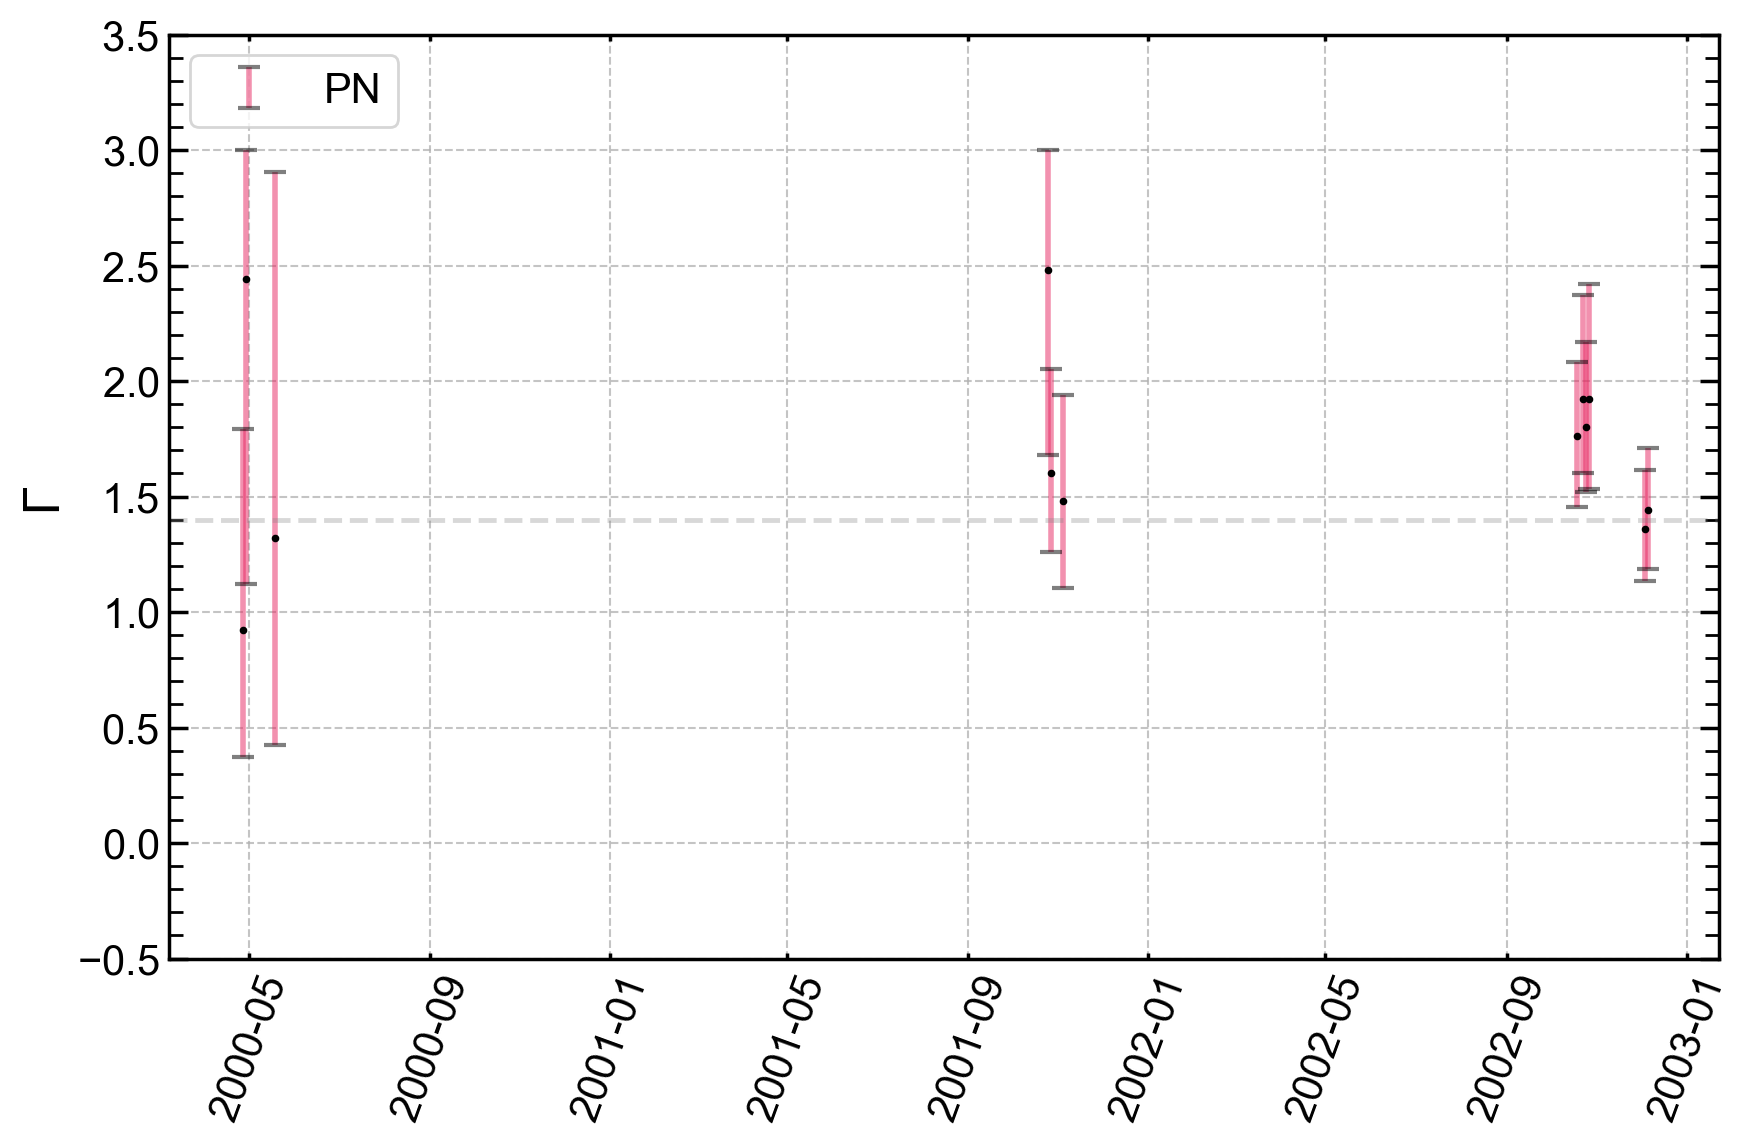

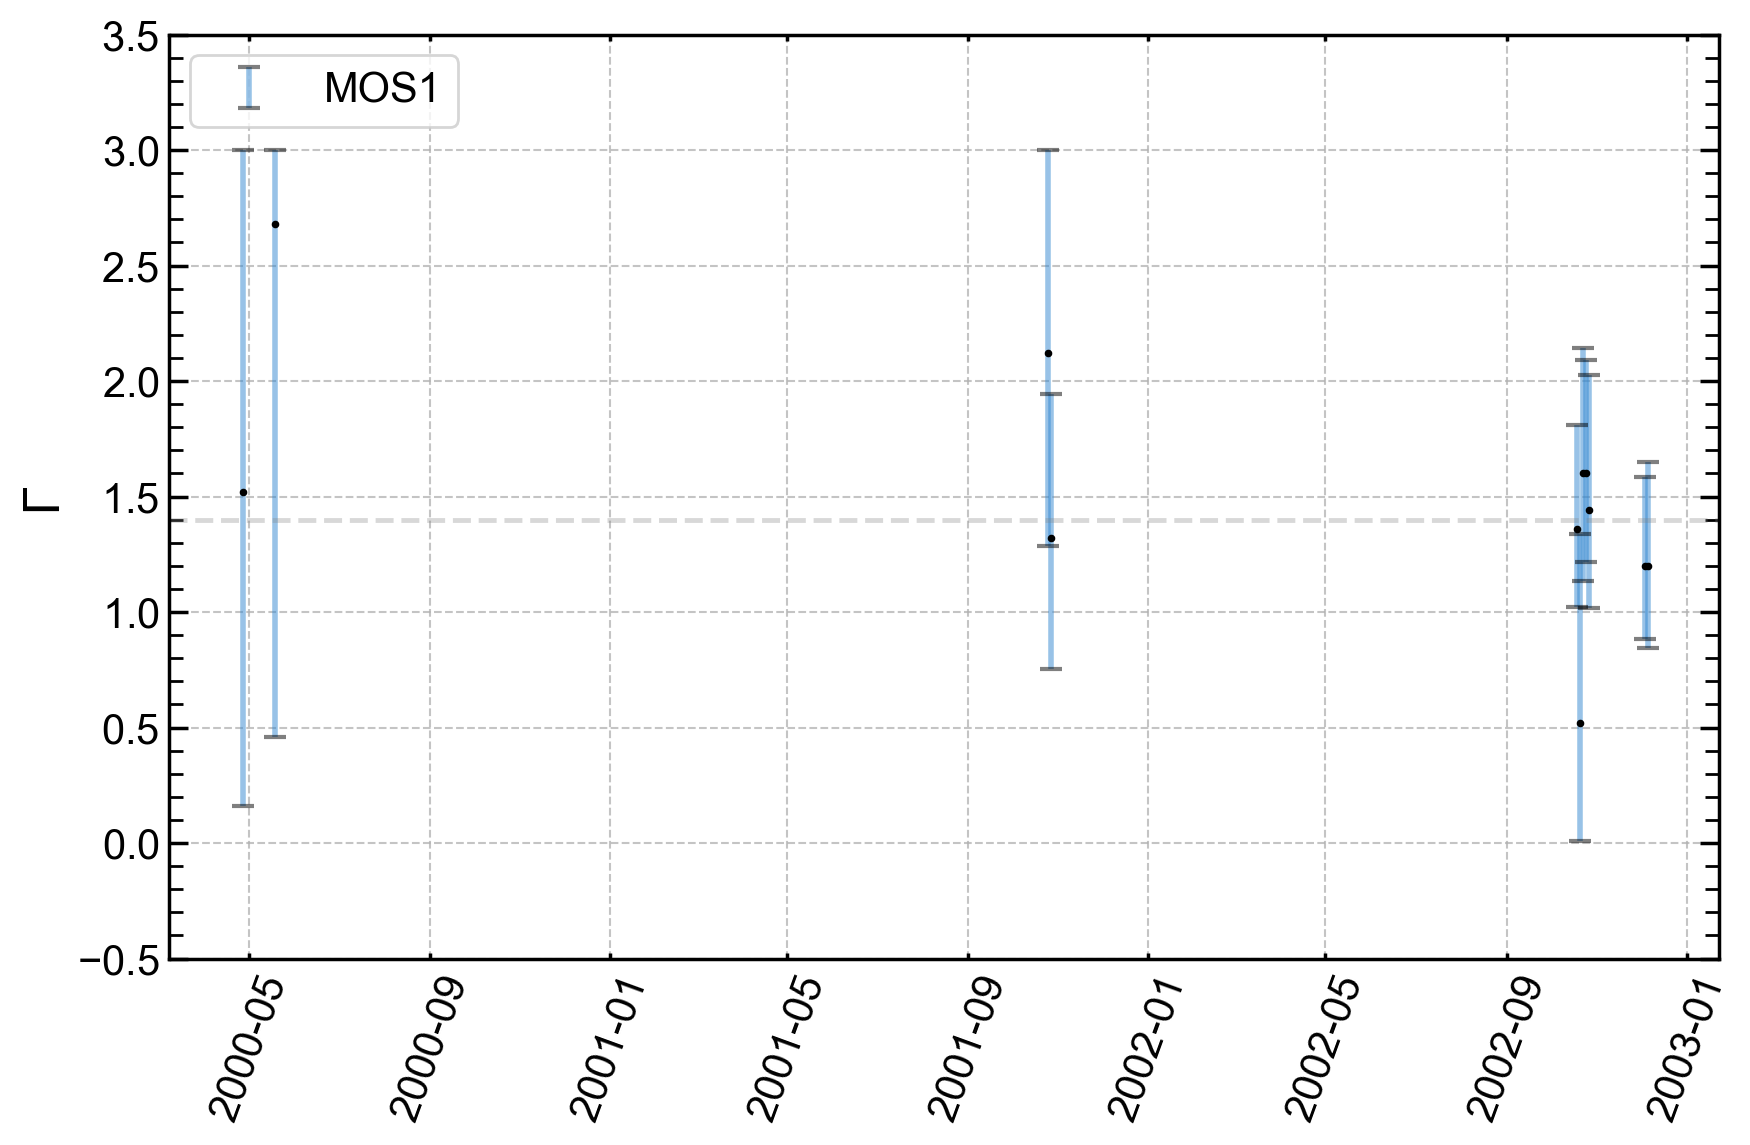

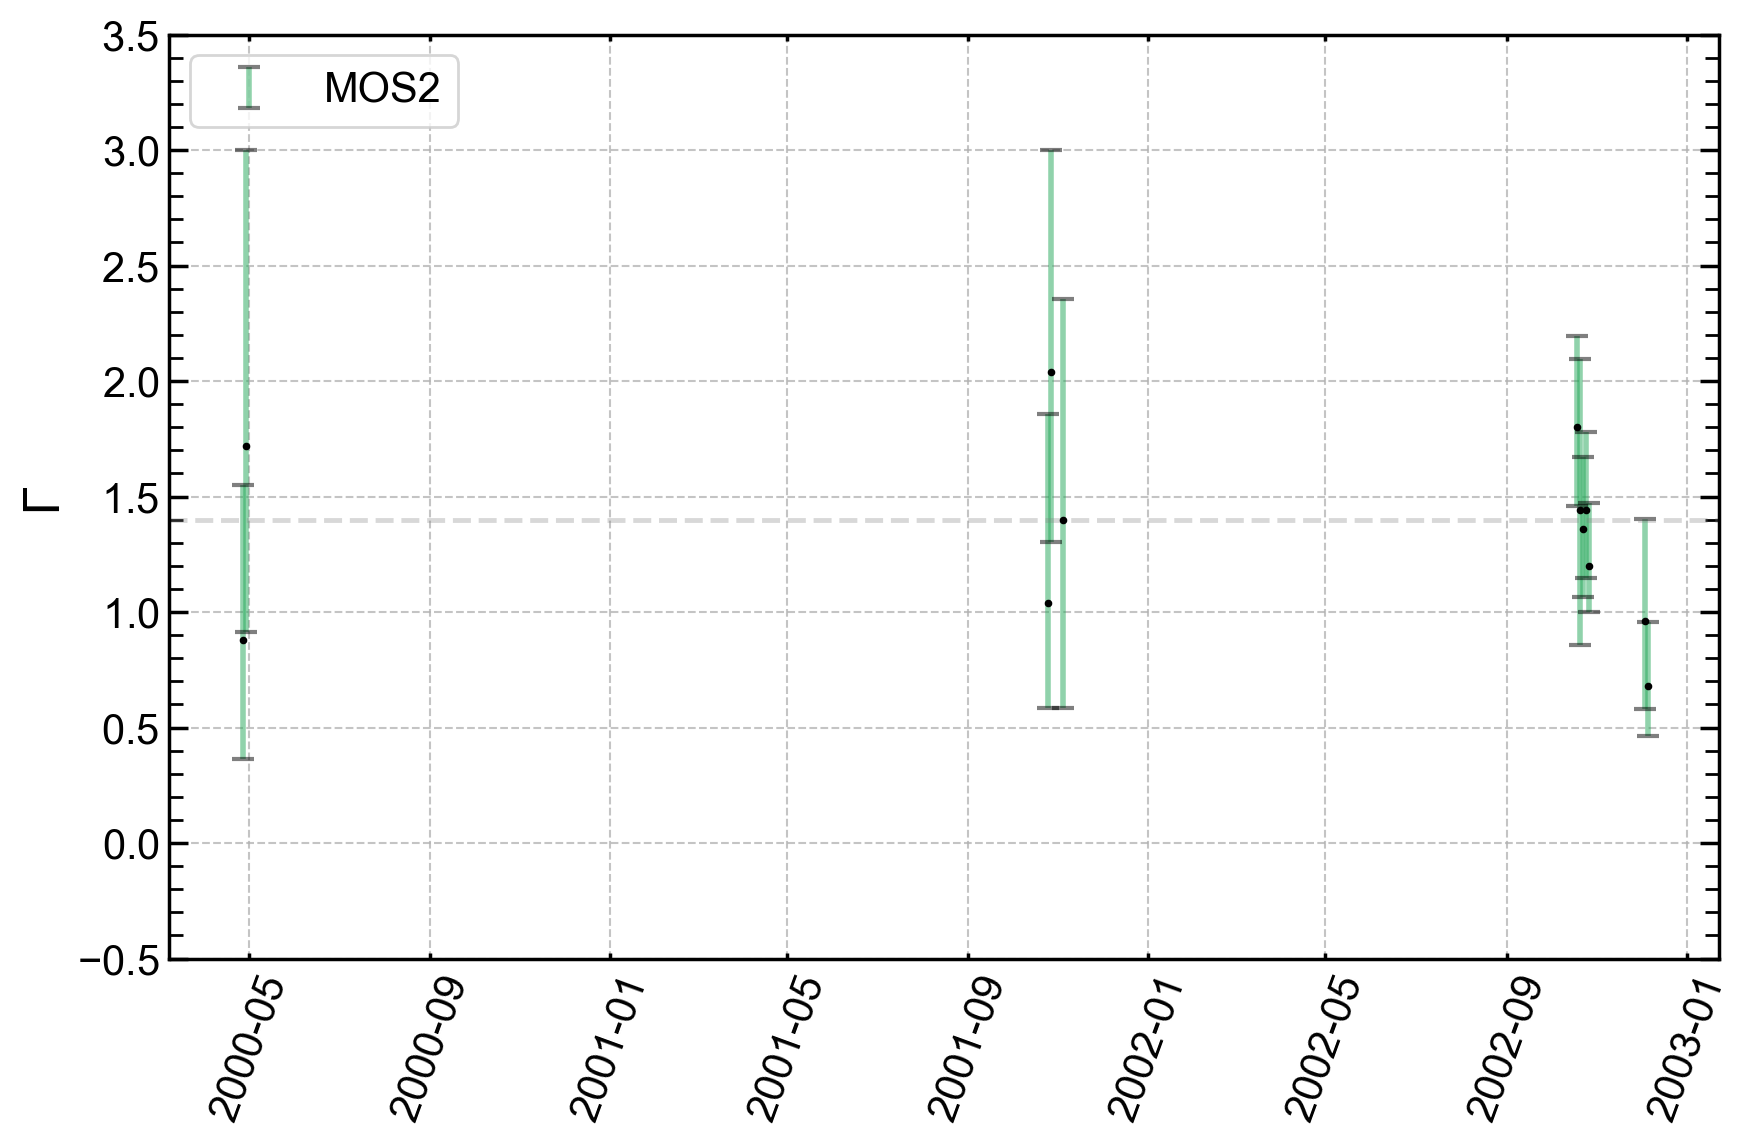

In [36]:
for df, title, color in zip(
    [src_1430_pn_df, src_1430_m1_df, src_1430_m2_df],
    ['PN', 'MOS1', 'MOS2'],
    ['C1', 'C0', 'C2']
):

    plot_date_gamma(df, title, color, uplim=3.5)